In [81]:
import os
import time
import copy
import json
import random
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.64 GB


In [163]:
class Config:
    # Paths
    DATA_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")
    IMAGES_DIR = DATA_DIR / "images"
    LABELS_DIR = DATA_DIR / "labels"
    SAVE_DIR = DATA_DIR / "new_model_checkpoints"

    # Data
    RAW_BANDS = 12
    IMG_SIZE = 128
    CATEGORICAL_CHANNELS = [7, 10] # QA Band, ESA WorldCover

    # Features (Baseline from old best: E1_raw12_NDWI)
    USE_NDWI = True
    USE_MNDWI = False
    USE_NDMI = False

    # Model
    # Note: Increasing BASE_FILTERS from 16 to 32 increases parameters.
    # With only 306 images, monitor for overfitting. If it overfits, reduce to 16.
    BASE_FILTERS = 32
    DEPTH = 5
    DROPOUT = 0.1

    # Training
    BATCH_SIZE = 8
    EPOCHS = 100
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 20
    GRAD_CLIP = 1.0

    # Loss: Options 'bce_dice', 'bce_tversky', 'focal_dice'
    # Recommendation: Start with 'bce_dice' (closest to baseline, most stable).
    LOSS_TYPE = 'bce_dice'

    # Scheduler
    SCHEDULER = 'cosine' # Options: 'cosine', 'plateau'

    # Misc
    NUM_WORKERS = 2

Config.SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [164]:
def validate_pairs(images_dir, labels_dir):
    pairs = []
    for img_path in sorted(images_dir.glob("*.tif")):
        label_path = labels_dir / f"{img_path.stem}.png"
        if label_path.exists():
            pairs.append((img_path, label_path))
    return pairs

all_pairs = validate_pairs(Config.IMAGES_DIR, Config.LABELS_DIR)
print(f"Total valid pairs found: {len(all_pairs)}")

Total valid pairs found: 306


In [165]:
def has_water(label_path):
    with rasterio.open(label_path) as src:
        return int(np.any(src.read(1) == 1))

# Stratification labels
strat_labels = np.array([has_water(lbl) for _, lbl in all_pairs])
print(f"Water presence distribution: Water={np.sum(strat_labels==1)}, No Water={np.sum(strat_labels==0)}")

# Step 1: افصل 10% Test
train_val_pairs, test_pairs, train_val_labels, test_labels = train_test_split(
    all_pairs, strat_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=strat_labels
)

# Step 2: من الـ90% الباقية، افصل 10% Validation من الإجمالي الأصلي
# يعني 10/90 = 11.11% من الـtrain_val
val_ratio = 0.10 / 0.90
train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    train_val_pairs, train_val_labels,
    test_size=val_ratio,
    random_state=SEED,
    stratify=train_val_labels
)

# ===== Verification =====
total = len(all_pairs)
print(f"\n{'='*50}")
print(f"Total images: {total}")
print(f"Train: {len(train_pairs)} ({100*len(train_pairs)/total:.1f}%)")
print(f"Val:   {len(val_pairs)} ({100*len(val_pairs)/total:.1f}%)")
print(f"Test:  {len(test_pairs)} ({100*len(test_pairs)/total:.1f}%)")
print(f"{'='*50}")

# Verify no-water images exist in all three splits
train_no_water = sum(1 for _, l in train_pairs if has_water(l) == 0)
val_no_water = sum(1 for _, l in val_pairs if has_water(l) == 0)
test_no_water = sum(1 for _, l in test_pairs if has_water(l) == 0)

print(f"\nNo-water images per split:")
print(f"  Train: {train_no_water}")
print(f"  Val:   {val_no_water}")
print(f"  Test:  {test_no_water}")

assert train_no_water > 0, "No no-water images in Train!"
assert val_no_water > 0, "No no-water images in Val!"
assert test_no_water > 0, "No no-water images in Test!"

# Verify percentages are close to 80/10/10
assert abs(len(train_pairs)/total - 0.80) < 0.03, "Train split not ~80%"
assert abs(len(val_pairs)/total - 0.10) < 0.03, "Val split not ~10%"
assert abs(len(test_pairs)/total - 0.10) < 0.03, "Test split not ~10%"

print("\n✓ Split verification passed.")

Water presence distribution: Water=261, No Water=45

Total images: 306
Train: 244 (79.7%)
Val:   31 (10.1%)
Test:  31 (10.1%)


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



No-water images per split:
  Train: 35
  Val:   5
  Test:  5

✓ Split verification passed.


In [166]:
def compute_ndwi_from_raw(img_path):
    """Load raw bands, compute NDWI from raw Green/NIR. No normalization."""
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float64)
    green = img[2]
    nir = img[4]
    ndwi = (green - nir) / (green + nir + 1e-6)
    return ndwi.astype(np.float32)


def evaluate_ndwi_threshold(pairs, threshold):
    """
    Evaluate a fixed NDWI threshold over a set of pairs.
    Returns pixel-accumulated metrics (global) and per-image stats.
    """
    eps = 1e-8
    tp = fp = fn = tn = 0
    per_image_records = []

    for img_path, mask_path in pairs:
        ndwi = compute_ndwi_from_raw(img_path)
        pred = (ndwi > threshold).astype(np.uint8)

        with rasterio.open(mask_path) as src:
            gt = (src.read(1) > 0).astype(np.uint8)

        # Accumulate global
        tp += int(((pred == 1) & (gt == 1)).sum())
        fp += int(((pred == 1) & (gt == 0)).sum())
        fn += int(((pred == 0) & (gt == 1)).sum())
        tn += int(((pred == 0) & (gt == 0)).sum())

        # Per-image (only for images with GT water)
        gt_has_water = gt.sum() > 0
        pred_has_water = pred.sum() > 0

        if gt_has_water:
            i_tp = int(((pred == 1) & (gt == 1)).sum())
            i_fp = int(((pred == 1) & (gt == 0)).sum())
            i_fn = int(((pred == 0) & (gt == 1)).sum())
            i_iou = i_tp / (i_tp + i_fp + i_fn + eps)
            i_prec = i_tp / (i_tp + i_fp + eps)
            i_rec = i_tp / (i_tp + i_fn + eps)
            i_f1 = 2 * i_prec * i_rec / (i_prec + i_rec + eps)
        else:
            # GT has no water: report separately, do not compute IoU
            i_iou = i_prec = i_rec = i_f1 = np.nan

        per_image_records.append({
            "gt_has_water": int(gt_has_water),
            "pred_has_water": int(pred_has_water),
            "iou": i_iou, "f1": i_f1, "precision": i_prec, "recall": i_rec,
            "no_water_correct": int((not gt_has_water) and (not pred_has_water)),
            "no_water_false_positive": int((not gt_has_water) and pred_has_water),
        })

    # Global metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)

    return {
        "global_accuracy": accuracy,
        "global_precision": precision,
        "global_recall": recall,
        "global_f1": f1,
        "global_iou": iou,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "per_image_df": pd.DataFrame(per_image_records),
    }

In [167]:
ndwi_thresholds = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

val_results = []
for thr in ndwi_thresholds:
    res = evaluate_ndwi_threshold(val_pairs, thr)
    val_results.append({
        "threshold": thr,
        "val_iou": res["global_iou"],
        "val_f1": res["global_f1"],
        "val_precision": res["global_precision"],
        "val_recall": res["global_recall"],
        "val_accuracy": res["global_accuracy"],
    })

val_df = pd.DataFrame(val_results)
print("NDWI Threshold Sweep on Validation Set:")
display(val_df)

# Select best threshold based on Validation IoU
best_ndwi_row = val_df.loc[val_df["val_iou"].idxmax()]
best_ndwi_thr = best_ndwi_row["threshold"]
print(f"\nBest NDWI threshold (by Val IoU): {best_ndwi_thr}")
print(f"  Val IoU: {best_ndwi_row['val_iou']:.4f}")
print(f"  Val F1:  {best_ndwi_row['val_f1']:.4f}")
print(f"  Val P:   {best_ndwi_row['val_precision']:.4f}")
print(f"  Val R:   {best_ndwi_row['val_recall']:.4f}")


NDWI Threshold Sweep on Validation Set:


,threshold,val_iou,val_f1,val_precision,val_recall,val_accuracy
0,-0.5,0.400470,0.571908,0.411496,0.937289,0.674218
1,-0.4,0.595744,0.746666,0.654960,0.868235,0.863212
2,-0.3,0.706738,0.828174,0.881825,0.780677,0.924789
3,-0.2,0.692388,0.818238,0.942728,0.722791,0.925445
4,-0.1,0.674077,0.805312,0.962605,0.692203,0.922294
5,0.0,0.656524,0.792653,0.970129,0.670070,0.918609
6,0.1,0.592134,0.743824,0.971874,0.602458,0.903653
7,0.2,0.543694,0.704407,0.973306,0.551924,0.892454
8,0.3,0.486766,0.654798,0.973572,0.493284,0.879245
9,0.4,0.341101,0.508688,0.965410,0.345321,0.845128



Best NDWI threshold (by Val IoU): -0.3
  Val IoU: 0.7067
  Val F1:  0.8282
  Val P:   0.8818
  Val R:   0.7807


In [168]:
test_res_ndwi = evaluate_ndwi_threshold(test_pairs, best_ndwi_thr)

print(f"NDWI Baseline on Test Set (threshold = {best_ndwi_thr}):")
print(f"  Test IoU:       {test_res_ndwi['global_iou']:.4f}")
print(f"  Test F1:        {test_res_ndwi['global_f1']:.4f}")
print(f"  Test Precision: {test_res_ndwi['global_precision']:.4f}")
print(f"  Test Recall:    {test_res_ndwi['global_recall']:.4f}")
print(f"  Test Accuracy:  {test_res_ndwi['global_accuracy']:.4f}")

# Per-image no-water handling
test_per_image = test_res_ndwi["per_image_df"]
n_no_water = (test_per_image["gt_has_water"] == 0).sum()
n_no_water_correct = test_per_image["no_water_correct"].sum()
n_no_water_fp = test_per_image["no_water_false_positive"].sum()
print(f"\nNo-water images in Test: {n_no_water}")
print(f"  Correctly predicted as no-water: {n_no_water_correct}")
print(f"  Falsely predicted water:          {n_no_water_fp}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


NDWI Baseline on Test Set (threshold = -0.3):
  Test IoU:       0.5052
  Test F1:        0.6712
  Test Precision: 0.6862
  Test Recall:    0.6569
  Test Accuracy:  0.8244

No-water images in Test: 5
  Correctly predicted as no-water: 1
  Falsely predicted water:          4


In [169]:
def compute_channel_stats(pairs, categorical_channels):
    """
    Compute mean and std for the 12 raw channels ONLY using the Training Set.
    Handle -9999 values in DEM channels (indices 8, 9) by replacing them with the channel mean.
    Returns arrays of length 12.
    """
    n_ch = Config.RAW_BANDS
    sums = np.zeros(n_ch)
    sums_sq = np.zeros(n_ch)
    n_px = np.zeros(n_ch)

    # First pass: compute mean for DEM channels ignoring -9999
    dem_means = np.zeros(n_ch)
    dem_counts = np.zeros(n_ch)

    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)
            for ch in [8, 9]: # MERIT DEM and Copernicus DEM
                valid_mask = img[ch] != -9999
                dem_means[ch] += img[ch][valid_mask].sum()
                dem_counts[ch] += valid_mask.sum()

    dem_means = dem_means / np.maximum(dem_counts, 1)

    # Second pass: compute stats replacing -9999 with channel mean and handling NaN/Inf
    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)
            for ch in [8, 9]:
                img[ch][img[ch] == -9999] = dem_means[ch]

            for ch in range(n_ch):
                if ch in categorical_channels:
                    continue
                flat = img[ch].reshape(-1)
                # Explicitly handle NaN/Inf before computing stats
                flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
                sums[ch] += flat.sum()
                sums_sq[ch] += (flat**2).sum()
                n_px[ch] += flat.shape[0]

    mean = sums / n_px
    var = np.clip((sums_sq / n_px) - mean**2, 1e-12, None)
    std = np.sqrt(var)

    # Ensure categorical channels have mean=0, std=1 (unused, but safe)
    for ch in categorical_channels:
        mean[ch] = 0.0
        std[ch] = 1.0

    return mean.astype(np.float32), std.astype(np.float32)

# Compute stats ONLY on Training Set
train_mean, train_std = compute_channel_stats(train_pairs, Config.CATEGORICAL_CHANNELS)
print(f"Train Mean shape: {train_mean.shape}, Std shape: {train_std.shape}")
print("Train Mean:", train_mean)
print("Train Std:", train_std)

# Save for inference
np.save(Config.SAVE_DIR / "train_mean.npy", train_mean)
np.save(Config.SAVE_DIR / "train_std.npy", train_std)

Train Mean shape: (12,), Std shape: (12,)
Train Mean: [ 398.6994    498.80075   833.2817    999.65765  2096.1665   1987.7577
 1374.1539      0.        278.03925   277.70383     0.          9.558664]
Train Std: [2.7297873e+02 3.2208539e+02 4.0916177e+02 5.8775342e+02 1.0592250e+03
 1.2130984e+03 9.7945312e+02 1.0000000e+00 4.4371057e+02 4.4528540e+02
 1.0000000e+00 2.7502573e+01]


/tmp/ipykernel_1687/2762797589.py:43: RuntimeWarning: invalid value encountered in divide
  mean = sums / n_px
/tmp/ipykernel_1687/2762797589.py:44: RuntimeWarning: invalid value encountered in divide
  var = np.clip((sums_sq / n_px) - mean**2, 1e-12, None)


In [170]:
def add_indices_np(img, feature_names):
    """Add NDWI, MNDWI, NDMI indices to the image array."""
    g, n, s = img[2], img[4], img[5] # Green, NIR, SWIR1
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI": feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI": feats.append((n - s) / (n + s + eps))

    if feats:
        idx = np.stack(feats, axis=0)
        idx = np.nan_to_num(idx, nan=0.0, posinf=0.0, neginf=0.0)
        idx = np.clip(idx, -1., 1.)
        img = np.concatenate([img, idx], axis=0)
    return img

def add_indices_torch(image, feature_names):
    """Torch version of add_indices."""
    g, n, s = image[2], image[4], image[5]
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI": feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI": feats.append((n - s) / (n + s + eps))

    if feats:
        idx = torch.stack(feats, dim=0)
        idx = torch.nan_to_num(idx, nan=0.0, posinf=0.0, neginf=0.0).clamp(-1., 1.)
        image = torch.cat([image, idx], dim=0)
    return image

In [171]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std, augment=False):
        self.pairs = pairs
        self.mean = torch.tensor(mean, dtype=torch.float32) # shape (12,)
        self.std = torch.tensor(std, dtype=torch.float32)   # shape (12,)
        self.augment = augment
        self.feature_names = []
        if Config.USE_NDWI: self.feature_names.append("NDWI")
        if Config.USE_MNDWI: self.feature_names.append("MNDWI")
        if Config.USE_NDMI: self.feature_names.append("NDMI")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32) # (12, H, W)
            # Handle -9999 in DEM channels (8, 9)
            for ch in [8, 9]:
                mask_9999 = image[ch] == -9999
                if mask_9999.any():
                    image[ch][mask_9999] = self.mean[ch].item()

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32) # (H, W)

        # Convert to tensor
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0) # (1, H, W)

        # Add features (NDWI, etc.) -> shape (12 + num_features, H, W)
        image = add_indices_torch(image, self.feature_names)

        # Normalize ONLY the first 12 raw channels (exclude categorical: 7, 10)
        # The added features (e.g., NDWI) are already in [-1, 1] and should NOT be normalized.
        for ch in range(Config.RAW_BANDS):
            if ch not in Config.CATEGORICAL_CHANNELS:
                image[ch] = (image[ch] - self.mean[ch]) / self.std[ch]

        # Data Augmentation (only for training)
        if self.augment:
            # Random Horizontal Flip
            if torch.rand(1).item() > 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[2])
            # Random Vertical Flip
            if torch.rand(1).item() > 0.5:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[1])
            # Random 90-degree rotation
            if torch.rand(1).item() > 0.5:
                k = torch.randint(1, 4, (1,)).item()
                image = torch.rot90(image, k=k, dims=[1, 2])
                mask = torch.rot90(mask, k=k, dims=[1, 2])
            # Add slight noise to continuous channels (only the raw 12)
            if torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image) * 0.05
                for ch in range(Config.RAW_BANDS):
                    if ch not in Config.CATEGORICAL_CHANNELS:
                        image[ch] += noise[ch]

        return image, mask

# Create Datasets
train_dataset = WaterSegDataset(train_pairs, train_mean, train_std, augment=True)
val_dataset = WaterSegDataset(val_pairs, train_mean, train_std, augment=False)
test_dataset = WaterSegDataset(test_pairs, train_mean, train_std, augment=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

# Sanity check
x, y = next(iter(train_loader))
print(f"Train batch shape: {x.shape}, Mask shape: {y.shape}")
assert x.shape[1] == 12 + len(train_dataset.feature_names), "Channel mismatch!"

Train batch shape: torch.Size([8, 13, 128, 128]), Mask shape: torch.Size([8, 1, 128, 128])


In [172]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.dropout(self.conv(x))

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base_f=32, depth=5, dropout=0.1):
        super().__init__()
        self.depth = depth

        # Encoder
        enc_ch = [base_f * (2 ** i) for i in range(depth)]
        self.encoders = nn.ModuleList()
        c_in = in_ch
        for oc in enc_ch:
            self.encoders.append(ConvBlock(c_in, oc, dropout=dropout))
            c_in = oc

        # Bottleneck
        bn_ch = enc_ch[-1] * 2
        self.bottleneck = ConvBlock(c_in, bn_ch, dropout=dropout)

        # Decoder
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        f = bn_ch
        for skip_ch in reversed(enc_ch):
            up_ch = f // 2
            self.upconvs.append(nn.ConvTranspose2d(f, up_ch, kernel_size=2, stride=2))
            self.decoders.append(ConvBlock(up_ch + skip_ch, up_ch, dropout=dropout))
            f = up_ch

        self.final = nn.Conv2d(f, out_ch, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.final(x)

# Sanity check
in_ch = 12 + (1 if Config.USE_NDWI else 0) + (1 if Config.USE_MNDWI else 0) + (1 if Config.USE_NDMI else 0)
model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS, depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)
with torch.no_grad():
    dummy = torch.randn(2, in_ch, 128, 128).to(DEVICE)
    out = model(dummy)
    print(f"Model Sanity Check: Input {dummy.shape} -> Output {out.shape}")
    assert out.shape == (2, 1, 128, 128)

Model Sanity Check: Input torch.Size([2, 13, 128, 128]) -> Output torch.Size([2, 1, 128, 128])


In [173]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        inter = (p * t).sum()
        return 1.0 - (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        tp = (p * t).sum()
        fp = ((1 - t) * p).sum()
        fn = (t * (1 - p)).sum()
        return 1.0 - (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)

class FocalLoss(nn.Module):
    """
    Correct Binary Focal Loss implementation.
    Supports pos_weight for class imbalance.
    """
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # Use BCE with pos_weight as the base loss
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none', pos_weight=self.pos_weight
        )
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

def compute_pos_weight(pairs):
    t, b = 0, 0
    for _, lbl in pairs:
        with rasterio.open(lbl) as s:
            m = s.read(1)
            t += int((m == 1).sum())
            b += int((m == 0).sum())
    return b / max(t, 1)

POS_WEIGHT = compute_pos_weight(train_pairs)
print(f"pos_weight (train): {POS_WEIGHT:.4f}")

def get_loss_fn(loss_type, pos_weight_val):
    pw = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)

    if loss_type == 'bce_dice':
        bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        dice = DiceLoss()
        return lambda logits, targets: bce(logits, targets) + dice(logits, targets)
    elif loss_type == 'bce_tversky':
        bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        tversky = TverskyLoss(alpha=0.7, beta=0.3)
        return lambda logits, targets: bce(logits, targets) + tversky(logits, targets)
    elif loss_type == 'focal_dice':
        focal = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pw)
        dice = DiceLoss()
        return lambda logits, targets: focal(logits, targets) + dice(logits, targets)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

loss_fn = get_loss_fn(Config.LOSS_TYPE, POS_WEIGHT)

pos_weight (train): 2.8228


In [174]:
class MetricsAccumulator:
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.tn = 0

    def update(self, logits, targets):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()
        self.tn += ((preds == 0) & (targets == 0)).sum().item()

    def compute(self):
        eps = 1e-8
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        accuracy = (self.tp + self.tn) / (self.tp + self.tn + self.fp + self.fn + eps)
        return {
            'iou': iou, 'f1': f1, 'precision': precision,
            'recall': recall, 'accuracy': accuracy
        }

# %% [markdown]
# ## 12. Training and Validation Loops
# %%
def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device):
    model.train()
    total_loss = 0.0
    metrics = MetricsAccumulator()

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)
        metrics.update(logits.detach(), y.detach())

    return total_loss / len(loader.dataset), metrics.compute()

@torch.no_grad()
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    metrics = MetricsAccumulator(threshold=threshold)

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
            loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        metrics.update(logits, y)

    return total_loss / len(loader.dataset), metrics.compute()

In [175]:
def run_training():
    set_seed(SEED)

    # Initialize model, optimizer, scheduler, scaler
    model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS, depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)

    if Config.SCHEDULER == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.EPOCHS, eta_min=1e-6)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

    scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))
    loss_fn = get_loss_fn(Config.LOSS_TYPE, POS_WEIGHT)

    best_val_iou = -float('inf')
    best_epoch = 0
    best_state = None
    no_improve = 0
    history = []

    print(f"Starting training for {Config.EPOCHS} epochs with {Config.LOSS_TYPE} loss...")
    print("Note: Early stopping may halt training before reaching max epochs if validation doesn't improve.")
    t0 = time.time()

    for epoch in range(1, Config.EPOCHS + 1):
        tr_loss, tr_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, DEVICE)
        vl_loss, vl_metrics = evaluate(model, val_loader, loss_fn, DEVICE, threshold=0.5)

        if Config.SCHEDULER == 'cosine':
            scheduler.step()
        else:
            scheduler.step(vl_metrics['iou'])

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss,
            'val_loss': vl_loss,
            **{f'val_{k}': v for k, v in vl_metrics.items()}
        })

        print(f"Ep {epoch:03d} | Tr Loss: {tr_loss:.4f} | Vl Loss: {vl_loss:.4f} | "
              f"Vl IoU: {vl_metrics['iou']:.4f} | Vl F1: {vl_metrics['f1']:.4f} | "
              f"P: {vl_metrics['precision']:.4f} | R: {vl_metrics['recall']:.4f}")

        # Select best model based on Validation IoU @ 0.5 (consistent with old baseline)
        if vl_metrics['iou'] > best_val_iou:
            best_val_iou = vl_metrics['iou']
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            # Save checkpoint
            torch.save(best_state, Config.SAVE_DIR / "best_model.pth")
            print(f"  -> New best model saved! (Val IoU @ 0.5: {best_val_iou:.4f})")
        else:
            no_improve += 1
            # Early stopping disabled — we want to see full training behavior
            if Config.PATIENCE is not None and no_improve >= Config.PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    train_time = time.time() - t0
    print(f"Training completed in {train_time/60:.2f} minutes.")
    print(f"Best Validation IoU @ 0.5: {best_val_iou:.4f} at epoch {best_epoch}")

    return history, best_state, best_epoch, best_val_iou, train_time

history, best_state, best_epoch, best_val_iou, train_time = run_training()


Starting training for 100 epochs with bce_dice loss...
Note: Early stopping may halt training before reaching max epochs if validation doesn't improve.


/tmp/ipykernel_1687/3100984837.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_1687/3421288559.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_1687/3421288559.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Ep 001 | Tr Loss: 1.5562 | Vl Loss: 1.3135 | Vl IoU: 0.3895 | Vl F1: 0.5607 | P: 0.4136 | R: 0.8702
  -> New best model saved! (Val IoU @ 0.5: 0.3895)
Ep 002 | Tr Loss: 1.2972 | Vl Loss: 1.0532 | Vl IoU: 0.3977 | Vl F1: 0.5691 | P: 0.4127 | R: 0.9165
  -> New best model saved! (Val IoU @ 0.5: 0.3977)
Ep 003 | Tr Loss: 1.1803 | Vl Loss: 0.9973 | Vl IoU: 0.5306 | Vl F1: 0.6933 | P: 0.5773 | R: 0.8677
  -> New best model saved! (Val IoU @ 0.5: 0.5306)
Ep 004 | Tr Loss: 1.1468 | Vl Loss: 0.9753 | Vl IoU: 0.6796 | Vl F1: 0.8092 | P: 0.8171 | R: 0.8015
  -> New best model saved! (Val IoU @ 0.5: 0.6796)
Ep 005 | Tr Loss: 1.0706 | Vl Loss: 0.9105 | Vl IoU: 0.7025 | Vl F1: 0.8253 | P: 0.8755 | R: 0.7804
  -> New best model saved! (Val IoU @ 0.5: 0.7025)
Ep 006 | Tr Loss: 1.0881 | Vl Loss: 0.9298 | Vl IoU: 0.5915 | Vl F1: 0.7433 | P: 0.6341 | R: 0.8981
Ep 007 | Tr Loss: 1.0998 | Vl Loss: 0.8923 | Vl IoU: 0.6132 | Vl F1: 0.7602 | P: 0.6827 | R: 0.8576
Ep 008 | Tr Loss: 1.0115 | Vl Loss: 0.8510 | 

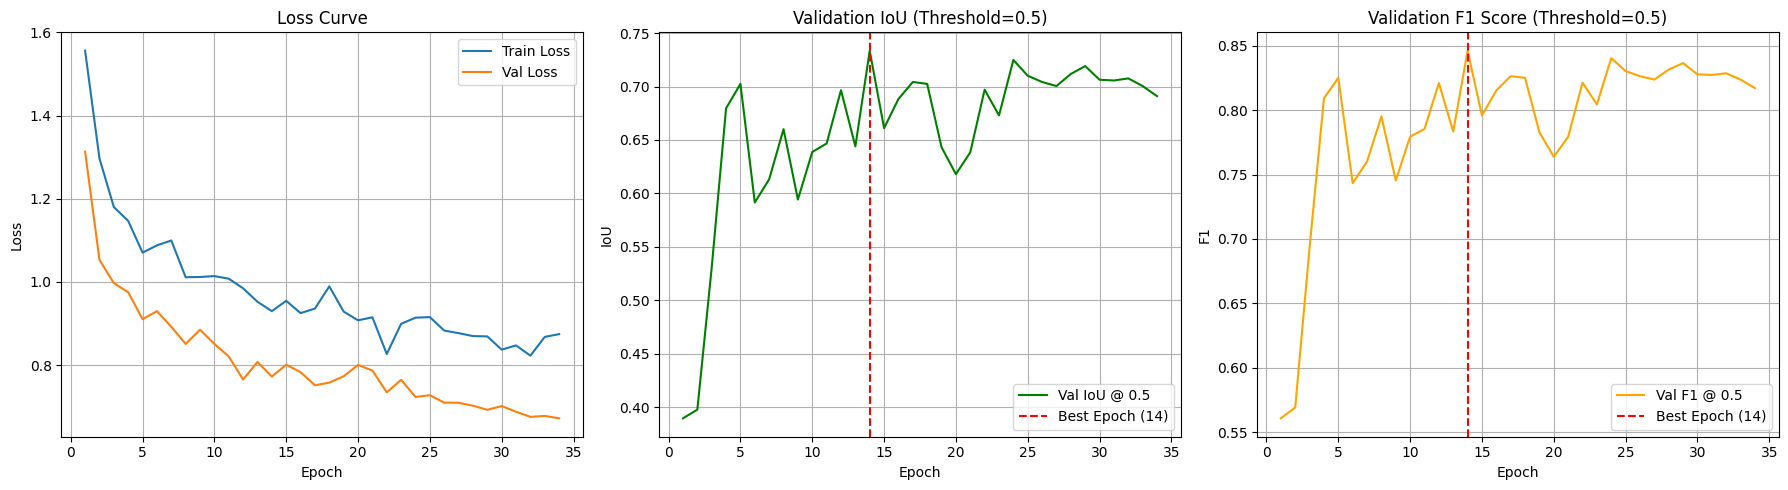

In [176]:
def plot_training_curves(history, best_epoch):
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss')
    axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # IoU
    axes[1].plot(df['epoch'], df['val_iou'], label='Val IoU @ 0.5', color='green')
    axes[1].axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    axes[1].set_title('Validation IoU (Threshold=0.5)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].legend()
    axes[1].grid(True)

    # F1
    axes[2].plot(df['epoch'], df['val_f1'], label='Val F1 @ 0.5', color='orange')
    axes[2].axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    axes[2].set_title('Validation F1 Score (Threshold=0.5)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history, best_epoch)

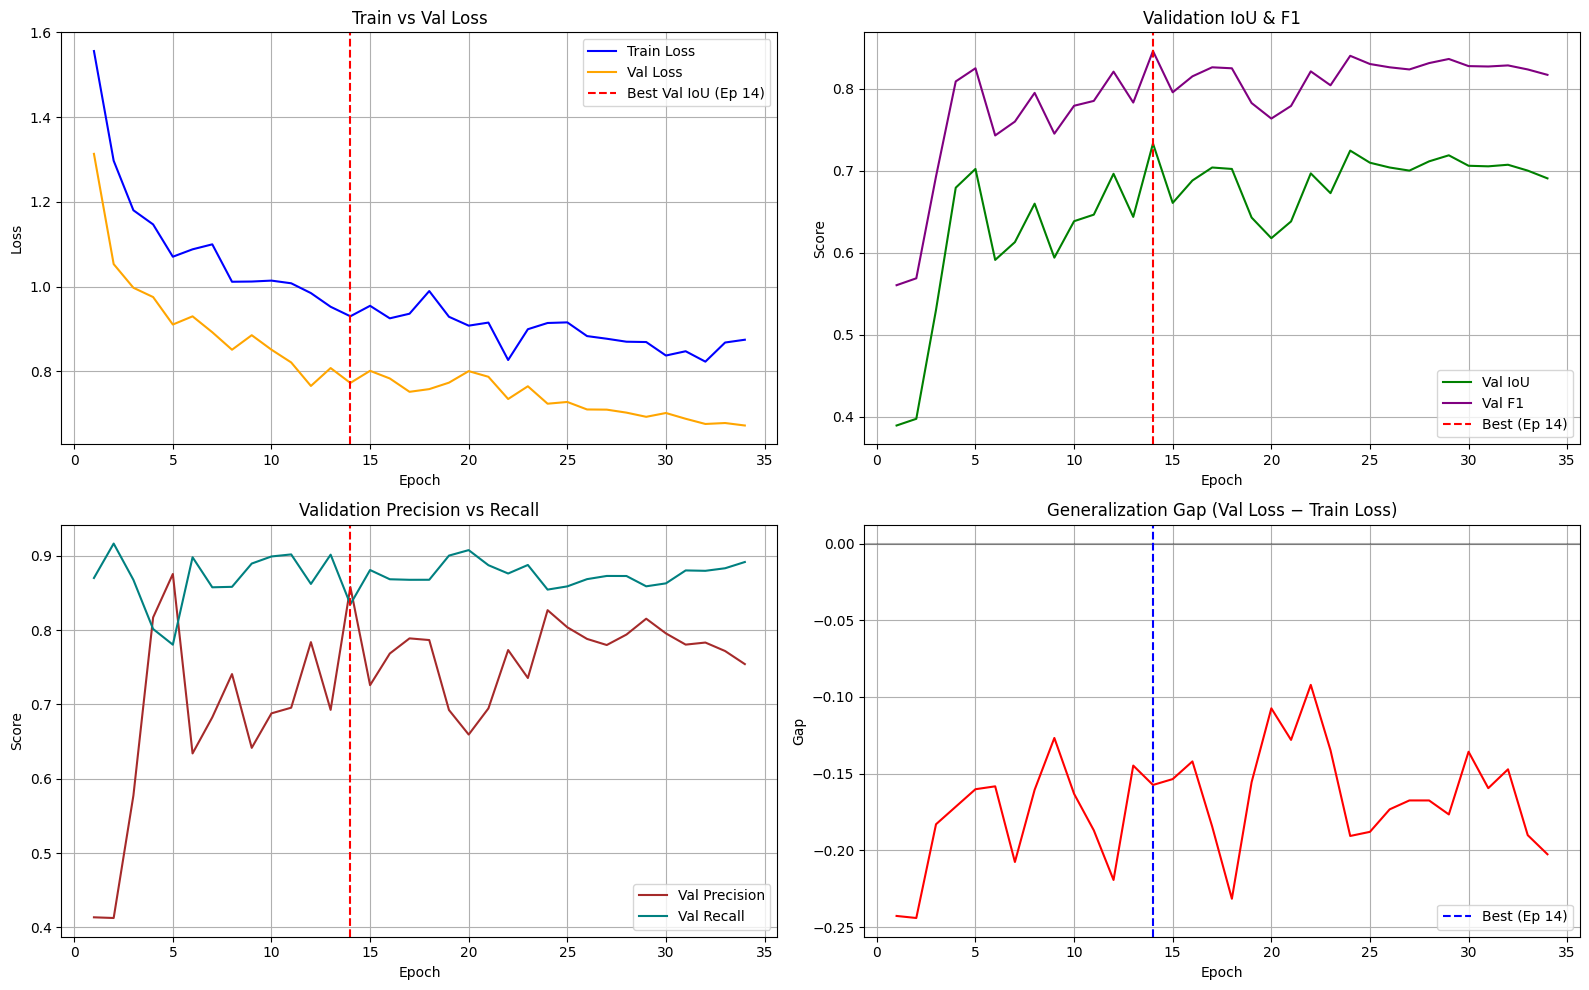


OVERFITTING DIAGNOSTIC SUMMARY
Best Val IoU:  0.7335 @ epoch 14
Final Val IoU: 0.6910 @ epoch 34
Final Train Loss: 0.8746
Final Val Loss:   0.6721
Overfitting started around epoch: 15
✓  Best epoch (14) is at 41% of training.
    → Training beyond this point is not improving Val IoU.


In [177]:
def plot_overfitting_diagnostic(history, best_epoch):
    df = pd.DataFrame(history)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Train vs Val Loss
    axes[0, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue')
    axes[0, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', color='orange')
    axes[0, 0].axvline(x=best_epoch, color='red', linestyle='--',
                       label=f'Best Val IoU (Ep {best_epoch})')
    axes[0, 0].set_title('Train vs Val Loss')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True)

    # 2. Val IoU and F1
    axes[0, 1].plot(df['epoch'], df['val_iou'], label='Val IoU', color='green')
    axes[0, 1].plot(df['epoch'], df['val_f1'], label='Val F1', color='purple')
    axes[0, 1].axvline(x=best_epoch, color='red', linestyle='--',
                       label=f'Best (Ep {best_epoch})')
    axes[0, 1].set_title('Validation IoU & F1')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Score')
    axes[0, 1].legend(); axes[0, 1].grid(True)

    # 3. Precision vs Recall
    axes[1, 0].plot(df['epoch'], df['val_precision'], label='Val Precision', color='brown')
    axes[1, 0].plot(df['epoch'], df['val_recall'], label='Val Recall', color='teal')
    axes[1, 0].axvline(x=best_epoch, color='red', linestyle='--')
    axes[1, 0].set_title('Validation Precision vs Recall')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend(); axes[1, 0].grid(True)

    # 4. Generalization Gap (Val Loss - Train Loss)
    gap = df['val_loss'] - df['train_loss']
    axes[1, 1].plot(df['epoch'], gap, color='red')
    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 1].axvline(x=best_epoch, color='blue', linestyle='--',
                       label=f'Best (Ep {best_epoch})')
    axes[1, 1].set_title('Generalization Gap (Val Loss − Train Loss)')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Gap')
    axes[1, 1].legend(); axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    # === Print summary ===
    print("\n" + "="*60)
    print("OVERFITTING DIAGNOSTIC SUMMARY")
    print("="*60)
    print(f"Best Val IoU:  {df['val_iou'].max():.4f} @ epoch {best_epoch}")
    print(f"Final Val IoU: {df['val_iou'].iloc[-1]:.4f} @ epoch {df['epoch'].iloc[-1]}")
    print(f"Final Train Loss: {df['train_loss'].iloc[-1]:.4f}")
    print(f"Final Val Loss:   {df['val_loss'].iloc[-1]:.4f}")

    # إمتى بدأ الـOverfitting (أول epoch الـVal Loss فيه بيزيد بعد الـbest)
    post_best = df[df['epoch'] > best_epoch]
    if len(post_best) > 0:
        overfit_start = post_best[post_best['val_loss'] > df.loc[df['epoch'] == best_epoch, 'val_loss'].values[0]]
        if len(overfit_start) > 0:
            print(f"Overfitting started around epoch: {overfit_start['epoch'].iloc[0]}")
        else:
            print("No clear overfitting detected (Val Loss kept decreasing or stable).")

    # هل الـBest Epoch قريب من الآخر؟
    total_epochs = df['epoch'].iloc[-1]
    if best_epoch / total_epochs > 0.9:
        print(f"⚠️  Best epoch ({best_epoch}) is near the end ({total_epochs}).")
        print("    → Consider training longer or the model hasn't converged yet.")
    else:
        print(f"✓  Best epoch ({best_epoch}) is at {100*best_epoch/total_epochs:.0f}% of training.")
        print("    → Training beyond this point is not improving Val IoU.")

plot_overfitting_diagnostic(history , best_epoch)

In [178]:
model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS, depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(Config.SAVE_DIR / "best_model.pth"))
model.eval()
print("Best model loaded successfully.")


Best model loaded successfully.


In [179]:
@torch.no_grad()
def evaluate_thresholds(model, loader, device, thresholds):
    model.eval()
    all_logits = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y)

    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    results = []
    for thr in thresholds:
        metrics = MetricsAccumulator(threshold=thr)
        metrics.update(all_logits, all_targets)
        res = metrics.compute()
        res['threshold'] = thr
        results.append(res)

    return pd.DataFrame(results)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_df = evaluate_thresholds(model, val_loader, DEVICE, thresholds)
print("Threshold Tuning on Validation Set:")
display(thr_df.sort_values('f1', ascending=False))

best_thr = thr_df.loc[thr_df['f1'].idxmax(), 'threshold']
print(f"Best Threshold selected: {best_thr}")

/tmp/ipykernel_1687/2040262098.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Threshold Tuning on Validation Set:


,iou,f1,precision,recall,accuracy,threshold
3,0.747886,0.855761,0.942323,0.783764,0.938658,0.6
2,0.733501,0.846265,0.858079,0.834772,0.929583,0.5
4,0.731025,0.844615,0.960842,0.753473,0.935634,0.7
1,0.692551,0.818352,0.775520,0.866191,0.910721,0.4
0,0.662285,0.796837,0.723627,0.886527,0.895043,0.3


Best Threshold selected: 0.6


In [180]:
print(f"Evaluating on Test Set using Best Threshold = {best_thr}...")

# Single evaluation with the chosen threshold
test_loss, test_metrics = evaluate(model, test_loader, loss_fn, DEVICE, threshold=best_thr)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test IoU: {test_metrics['iou']:.4f}")
print(f"Test F1: {test_metrics['f1']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall: {test_metrics['recall']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")

Evaluating on Test Set using Best Threshold = 0.6...


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_1687/3421288559.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Test Loss: 1.0464
Test IoU: 0.5206
Test F1: 0.6848
Test Precision: 0.9091
Test Recall: 0.5492
Test Accuracy: 0.8620


In [181]:
# ===== Classical NDWI Baseline =====
print("="*60)
print("CLASSICAL NDWI BASELINE")
print("="*60)
print(f"Best validation threshold: {best_ndwi_thr}")
print(f"Validation IoU: {best_ndwi_row['val_iou']:.4f}")
print(f"Validation F1:  {best_ndwi_row['val_f1']:.4f}")
print(f"Test IoU:       {test_res_ndwi['global_iou']:.4f}")
print(f"Test F1:        {test_res_ndwi['global_f1']:.4f}")

# ===== Deep Learning Model =====
# NOTE: افترض إن عندك test_metrics من تقييم الموديل على الـTest
# ومتغير best_val_iou من الـtraining loop (بالـthreshold 0.5)
print("\n" + "="*60)
print("DEEP LEARNING MODEL (U-Net)")
print("="*60)
print(f"Validation IoU: {best_val_iou:.4f}")
print(f"Validation F1:  {max(history, key=lambda x: x['val_iou'])['val_f1']:.4f}")
print(f"Test IoU:       {test_res['iou']:.4f}")
print(f"Test F1:        {test_res['f1']:.4f}")
print(f"Test Precision: {test_res['precision']:.4f}")
print(f"Test Recall:    {test_res['recall']:.4f}")

# ===== Side-by-side table =====
comparison = pd.DataFrame([
    {
        "Method": "Classical NDWI",
        "Best Val Threshold": best_ndwi_thr,
        "Val IoU": best_ndwi_row['val_iou'],
        "Val F1": best_ndwi_row['val_f1'],
        "Test IoU": test_res_ndwi['global_iou'],
        "Test F1": test_res_ndwi['global_f1'],
    },
    {
        "Method": "U-Net (Deep Learning)",
        "Best Val Threshold": 0.5,
        "Val IoU": best_val_iou,
        "Val F1": max(history, key=lambda x: x['val_iou'])['val_f1'],
        "Test IoU": test_res['iou'],
        "Test F1": test_res['f1'],
    },
])
display(comparison)

CLASSICAL NDWI BASELINE
Best validation threshold: -0.3
Validation IoU: 0.7067
Validation F1:  0.8282
Test IoU:       0.5052
Test F1:        0.6712

DEEP LEARNING MODEL (U-Net)
Validation IoU: 0.7335
Validation F1:  0.8463
Test IoU:       0.5258
Test F1:        0.6892
Test Precision: 0.8935
Test Recall:    0.5610


,Method,Best Val Threshold,Val IoU,Val F1,Test IoU,Test F1
0,Classical NDWI,-0.3,0.706738,0.828174,0.505171,0.671248
1,U-Net (Deep Learning),0.5,0.733501,0.846265,0.525818,0.689228


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_1687/92848732.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):



--- Final Test Metrics (Single Evaluation) ---
Test IoU: 0.5206
Test F1: 0.6848
Test Precision: 0.9091
Test Recall: 0.5492
Test Accuracy: 0.8620

Confusion Matrix (Pixel-level):


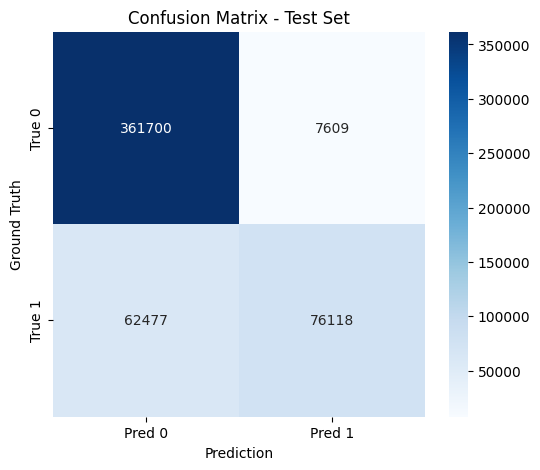

In [182]:
metrics_acc = MetricsAccumulator(threshold=best_thr)
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(x)
        metrics_acc.update(logits, y)
test_res = metrics_acc.compute()

print("\n--- Final Test Metrics (Single Evaluation) ---")
print(f"Test IoU: {test_res['iou']:.4f}")
print(f"Test F1: {test_res['f1']:.4f}")
print(f"Test Precision: {test_res['precision']:.4f}")
print(f"Test Recall: {test_res['recall']:.4f}")
print(f"Test Accuracy: {test_res['accuracy']:.4f}")

# Confusion Matrix
print("\nConfusion Matrix (Pixel-level):")
cm = np.array([[metrics_acc.tn, metrics_acc.fp],
               [metrics_acc.fn, metrics_acc.tp]])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_1687/3094356060.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


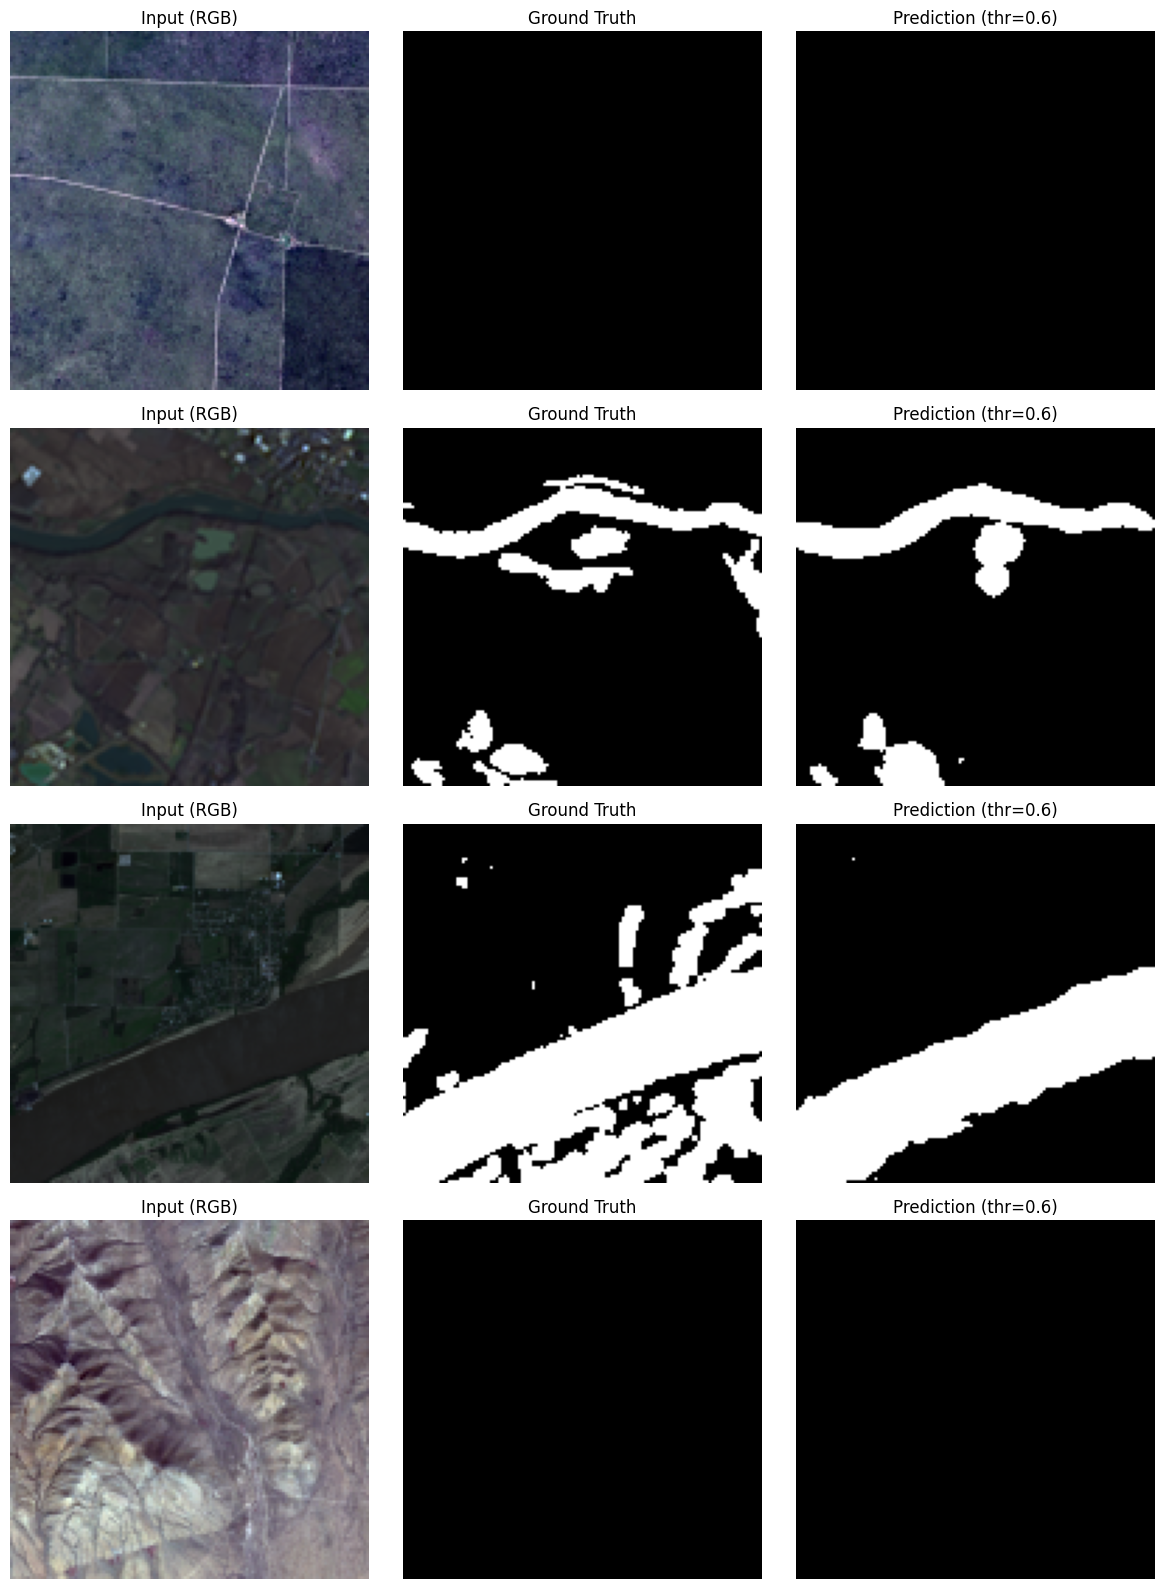

In [183]:
def visualize_predictions(model, loader, device, threshold, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    samples_shown = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(enabled=(device.type == 'cuda')):
                logits = model(x)
            preds = (torch.sigmoid(logits) > threshold).float()

            for i in range(x.size(0)):
                if samples_shown >= num_samples:
                    break

                # Use RGB channels for visualization (Red=3, Green=2, Blue=1)
                rgb = x[i, [3, 2, 1]].cpu().numpy().transpose(1, 2, 0)
                # Normalize RGB for display
                rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

                gt = y[i, 0].cpu().numpy()
                pred = preds[i, 0].cpu().numpy()

                axes[samples_shown, 0].imshow(rgb)
                axes[samples_shown, 0].set_title('Input (RGB)')
                axes[samples_shown, 0].axis('off')

                axes[samples_shown, 1].imshow(gt, cmap='gray')
                axes[samples_shown, 1].set_title('Ground Truth')
                axes[samples_shown, 1].axis('off')

                axes[samples_shown, 2].imshow(pred, cmap='gray')
                axes[samples_shown, 2].set_title(f'Prediction (thr={threshold})')
                axes[samples_shown, 2].axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, DEVICE, best_thr, num_samples=4)


In [184]:
ANALYSIS_THRESHOLD = globals().get("best_thr", 0.5)  # reuse best_thr from previous section if available
print(f"Using threshold for analysis: {ANALYSIS_THRESHOLD}")

# Ensure model is in eval mode
model.eval()

Using threshold for analysis: 0.6


UNet(
  (encoders): ModuleList(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (dropout): Dropout2d(p=0.1, inplace=False)
    )
    (1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [185]:
@torch.no_grad()
def collect_test_predictions(model, loader, device):
    model.eval()
    all_logits = []
    all_targets = []
    all_indices = []
    idx_counter = 0

    for x, y in loader:
        x = x.to(device)
        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y.cpu())
        all_indices.extend(range(idx_counter, idx_counter + x.size(0)))
        idx_counter += x.size(0)

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    return all_logits, all_targets, all_indices

test_logits, test_targets, test_indices = collect_test_predictions(model, test_loader, DEVICE)
test_probs = torch.sigmoid(test_logits)  # (N, 1, H, W)

print(f"Collected predictions: logits {test_logits.shape}, targets {test_targets.shape}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_1687/3573113444.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Collected predictions: logits torch.Size([31, 1, 128, 128]), targets torch.Size([31, 1, 128, 128])


In [186]:
def per_image_metrics(probs, targets, threshold=0.5):
    """
    probs: (N, 1, H, W) in [0,1]
    targets: (N, 1, H, W) in {0,1}
    Returns DataFrame with per-image stats.
    """
    eps = 1e-8
    N = probs.shape[0]
    records = []

    for i in range(N):
        p = (probs[i] > threshold).float()
        t = targets[i].float()

        tp = ((p == 1) & (t == 1)).sum().item()
        fp = ((p == 1) & (t == 0)).sum().item()
        fn = ((p == 0) & (t == 1)).sum().item()
        tn = ((p == 0) & (t == 0)).sum().item()
        total = tp + fp + fn + tn + eps

        iou = tp / (tp + fp + fn + eps)
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)

        records.append({
            "index": i,
            "iou": iou,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "gt_water_pct": (t.sum().item() / total) * 100,
            "pred_water_pct": (p.sum().item() / total) * 100,
            "fp_pct": (fp / total) * 100,
            "fn_pct": (fn / total) * 100,
            "tp_pixels": tp,
            "fp_pixels": fp,
            "fn_pixels": fn,
            "tn_pixels": tn,
            "gt_has_water": int(t.sum().item() > 0),
            "pred_has_water": int(p.sum().item() > 0),
        })
    return pd.DataFrame(records)

df_metrics = per_image_metrics(test_probs, test_targets, threshold=ANALYSIS_THRESHOLD)
print(f"Per-image metrics computed for {len(df_metrics)} test images.")
display(df_metrics.describe())

Per-image metrics computed for 31 test images.


,index,iou,f1,precision,recall,gt_water_pct,pred_water_pct,fp_pct,fn_pct,tp_pixels,fp_pixels,fn_pixels,tn_pixels,gt_has_water,pred_has_water
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,15.000000,0.361221,0.456064,0.653223,0.385561,27.287637,16.484808,1.498118,12.300947,2455.419355,245.451613,2015.387097,11667.741935,0.838710,0.709677
std,9.092121,0.302043,0.352253,0.427389,0.328323,25.015798,16.716139,2.055909,14.847249,2486.979370,336.840203,2432.573352,4292.383898,0.373878,0.461414
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4225.000000,0.000000,0.000000
25%,7.500000,0.000000,0.000000,0.000000,0.000000,2.401733,0.000000,0.000000,1.278687,0.000000,0.000000,209.500000,8224.000000,1.000000,0.000000
50%,15.000000,0.399603,0.571023,0.888205,0.400188,23.413086,16.973877,0.335693,5.273437,2649.000000,55.000000,864.000000,12497.000000,1.000000,1.000000
75%,22.500000,0.559806,0.717777,0.946457,0.610546,42.587280,25.616455,2.249146,16.766357,3866.000000,368.500000,2747.000000,15990.500000,1.000000,1.000000
max,30.000000,0.909507,0.952609,1.000000,0.967256,72.033691,62.542725,9.179687,49.340820,9729.000000,1504.000000,8084.000000,16384.000000,1.000000,1.000000


In [187]:
def visualize_sample(idx, probs, targets, threshold=0.5, figsize=(20, 10)):
    """
    6-panel visualization for a single test image.
    Uses the existing test_dataset for RGB display (via test_loader order).
    """
    # Fetch the actual image tensor from the dataset to display RGB properly
    img_tensor, gt_tensor = test_dataset[idx]
    # RGB composite: Red=3, Green=2, Blue=1 (raw order: 0=Coastal,1=Blue,2=Green,3=Red,4=NIR,...)
    rgb = img_tensor[[3, 2, 1]].numpy().transpose(1, 2, 0)
    # Percentile stretch for visibility
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

    prob_map = probs[idx, 0].numpy()
    gt = targets[idx, 0].numpy().astype(np.uint8)
    pred = (prob_map > threshold).astype(np.uint8)

    # Error map: 0=TN, 1=FP, 2=FN, 3=TP
    error_map = np.zeros_like(gt, dtype=np.uint8)
    error_map[(gt == 0) & (pred == 0)] = 0  # TN
    error_map[(gt == 0) & (pred == 1)] = 1  # FP
    error_map[(gt == 1) & (pred == 0)] = 2  # FN
    error_map[(gt == 1) & (pred == 1)] = 3  # TP

    # Overlay: GT in green, Pred in red, overlap in yellow
    overlay = np.zeros((*gt.shape, 3), dtype=np.float32)
    overlay[..., 1] = gt * 1.0        # GT -> green
    overlay[..., 0] = pred * 1.0      # Pred -> red
    # Where both: yellow (R+G)

    from matplotlib.colors import ListedColormap
    error_cmap = ListedColormap(["black", "red", "blue", "green"])

    fig, axes = plt.subplots(1, 6, figsize=figsize)
    axes[0].imshow(rgb); axes[0].set_title("RGB (R,G,B = 3,2,1)"); axes[0].axis("off")
    axes[1].imshow(gt, cmap="gray", vmin=0, vmax=1); axes[1].set_title("Ground Truth"); axes[1].axis("off")
    im = axes[2].imshow(prob_map, cmap="viridis", vmin=0, vmax=1); axes[2].set_title("Predicted Probability"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    axes[3].imshow(pred, cmap="gray", vmin=0, vmax=1); axes[3].set_title(f"Binary Pred (thr={threshold})"); axes[3].axis("off")
    axes[4].imshow(overlay); axes[4].set_title("Overlay: GT=Green, Pred=Red"); axes[4].axis("off")
    axes[5].imshow(error_map, cmap=error_cmap, vmin=0, vmax=3)
    axes[5].set_title("Error Map: TN=Black, FP=Red, FN=Blue, TP=Green"); axes[5].axis("off")

    m = df_metrics.iloc[idx]
    fig.suptitle(
        f"Idx {idx} | IoU={m['iou']:.3f} F1={m['f1']:.3f} P={m['precision']:.3f} R={m['recall']:.3f} | "
        f"GT water={m['gt_water_pct']:.2f}% Pred water={m['pred_water_pct']:.2f}% | "
        f"FP={m['fp_pct']:.2f}% FN={m['fn_pct']:.2f}%",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


def show_group(indices, title, threshold=0.5):
    print(f"\n{'='*80}\n{title}\n{'='*80}")
    for idx in indices:
        visualize_sample(idx, test_probs, test_targets, threshold=threshold)


GROUP 1 — Best Predictions (highest IoU)


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


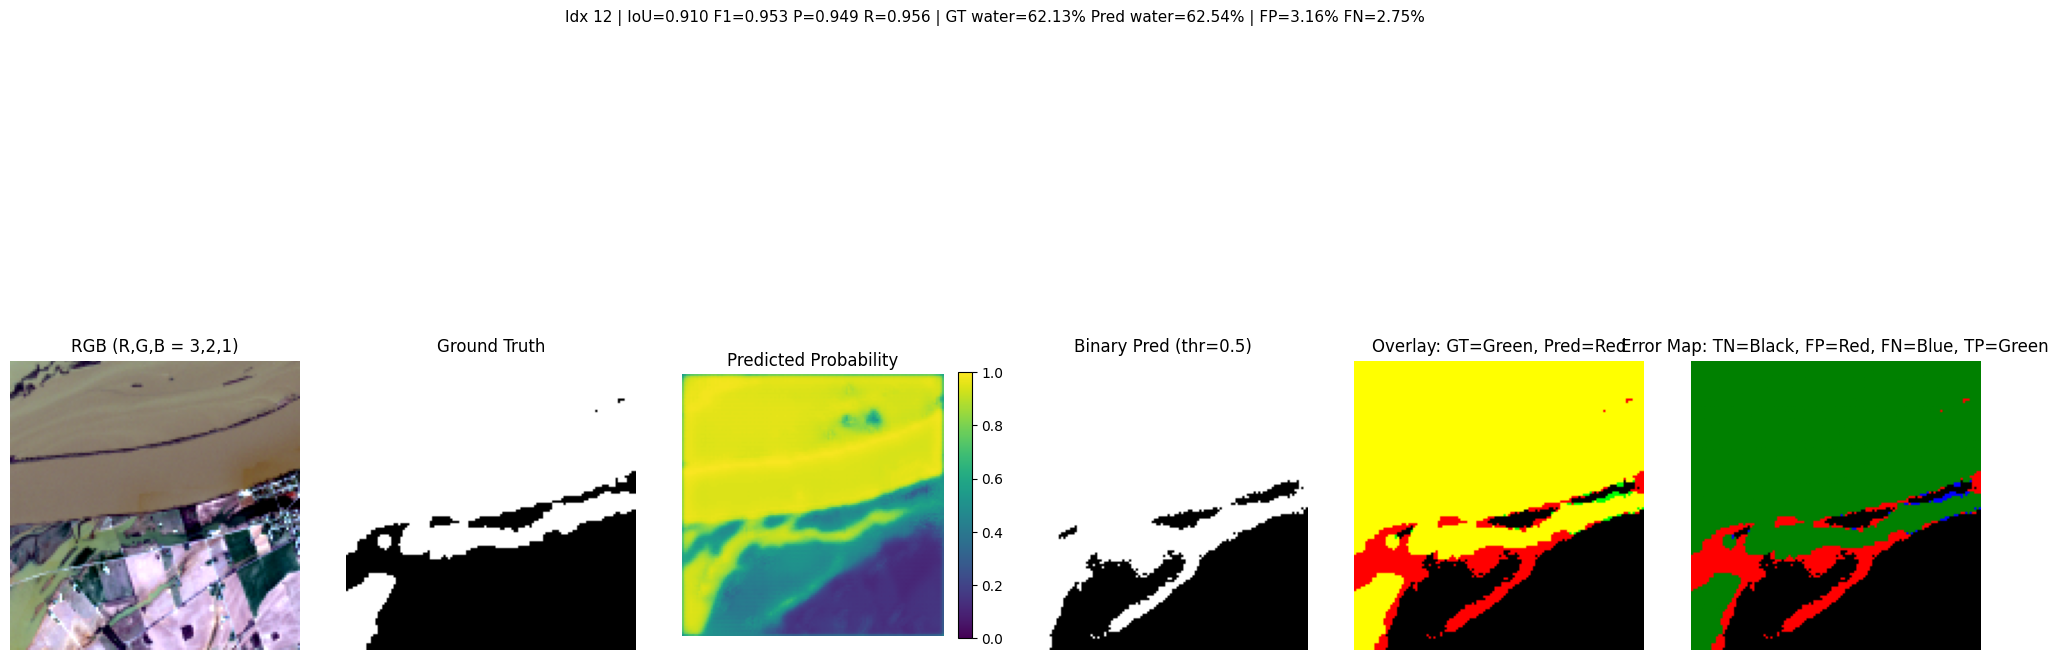

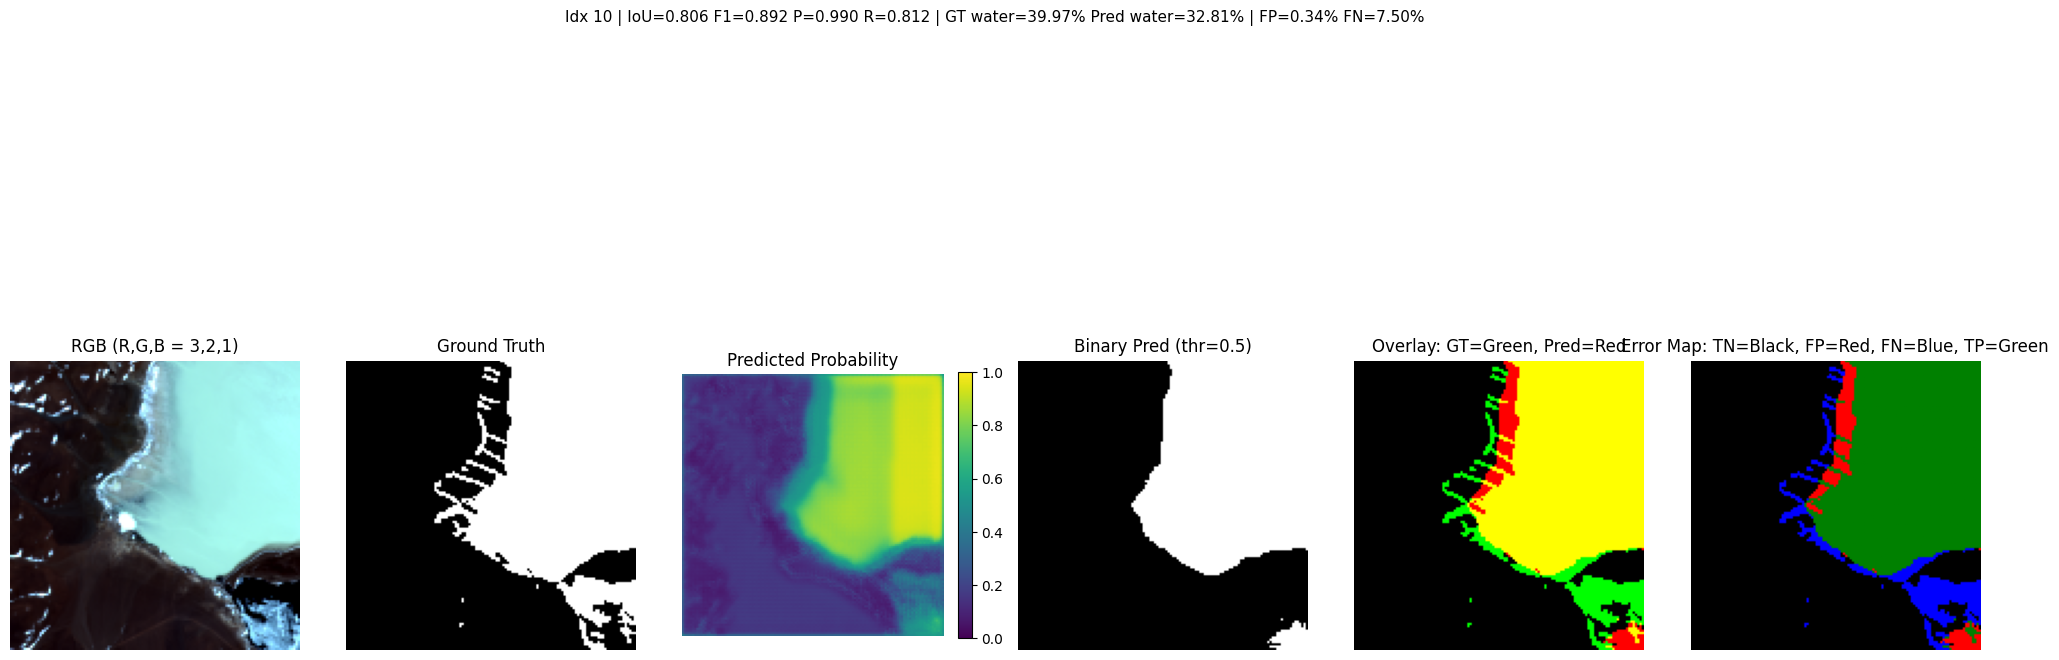

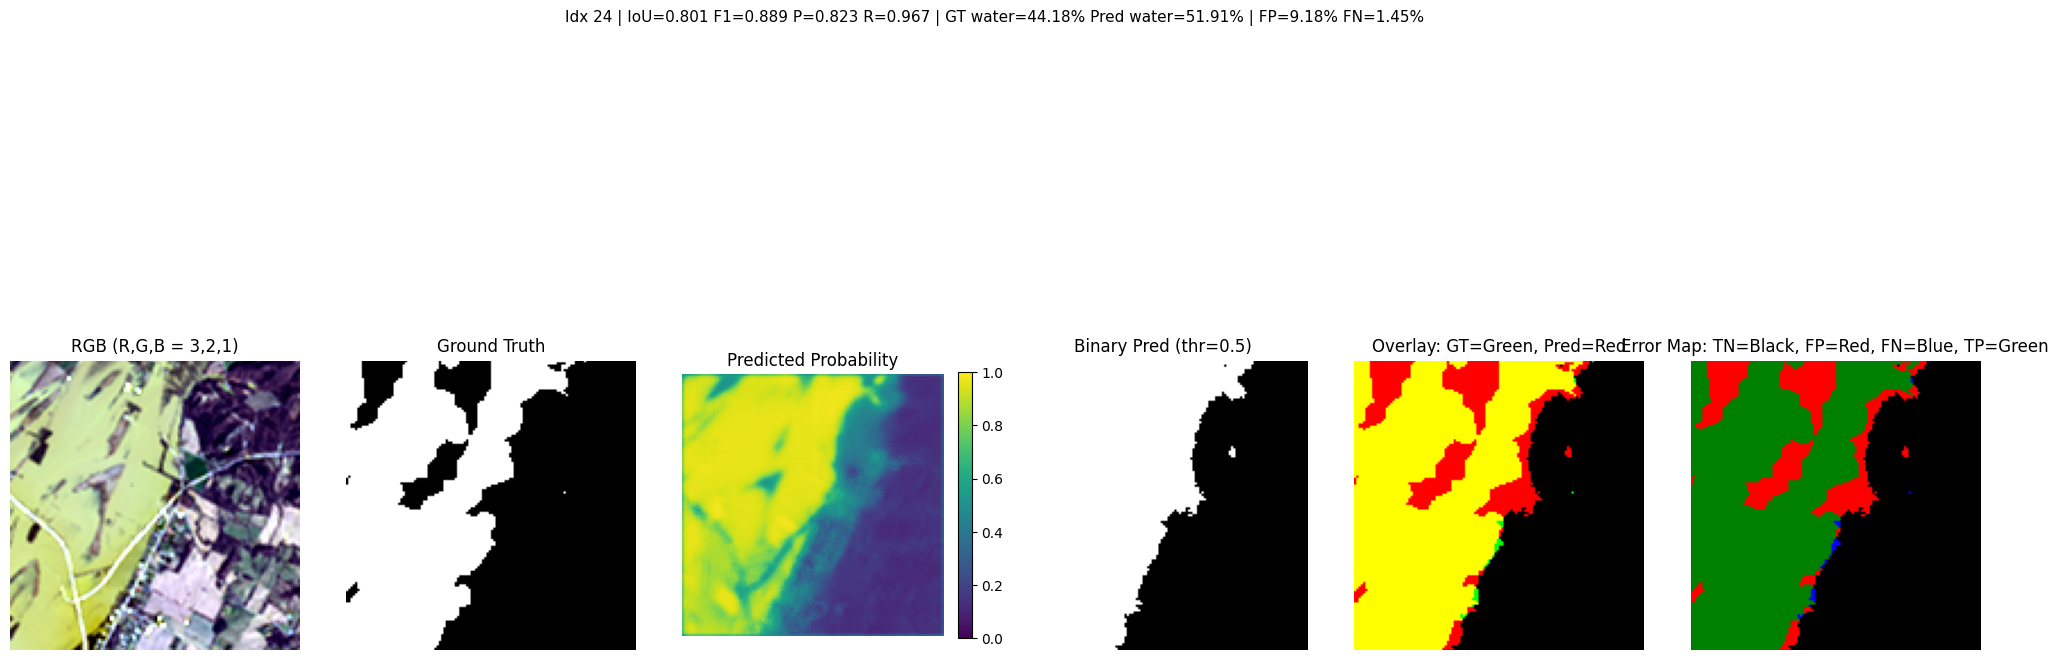

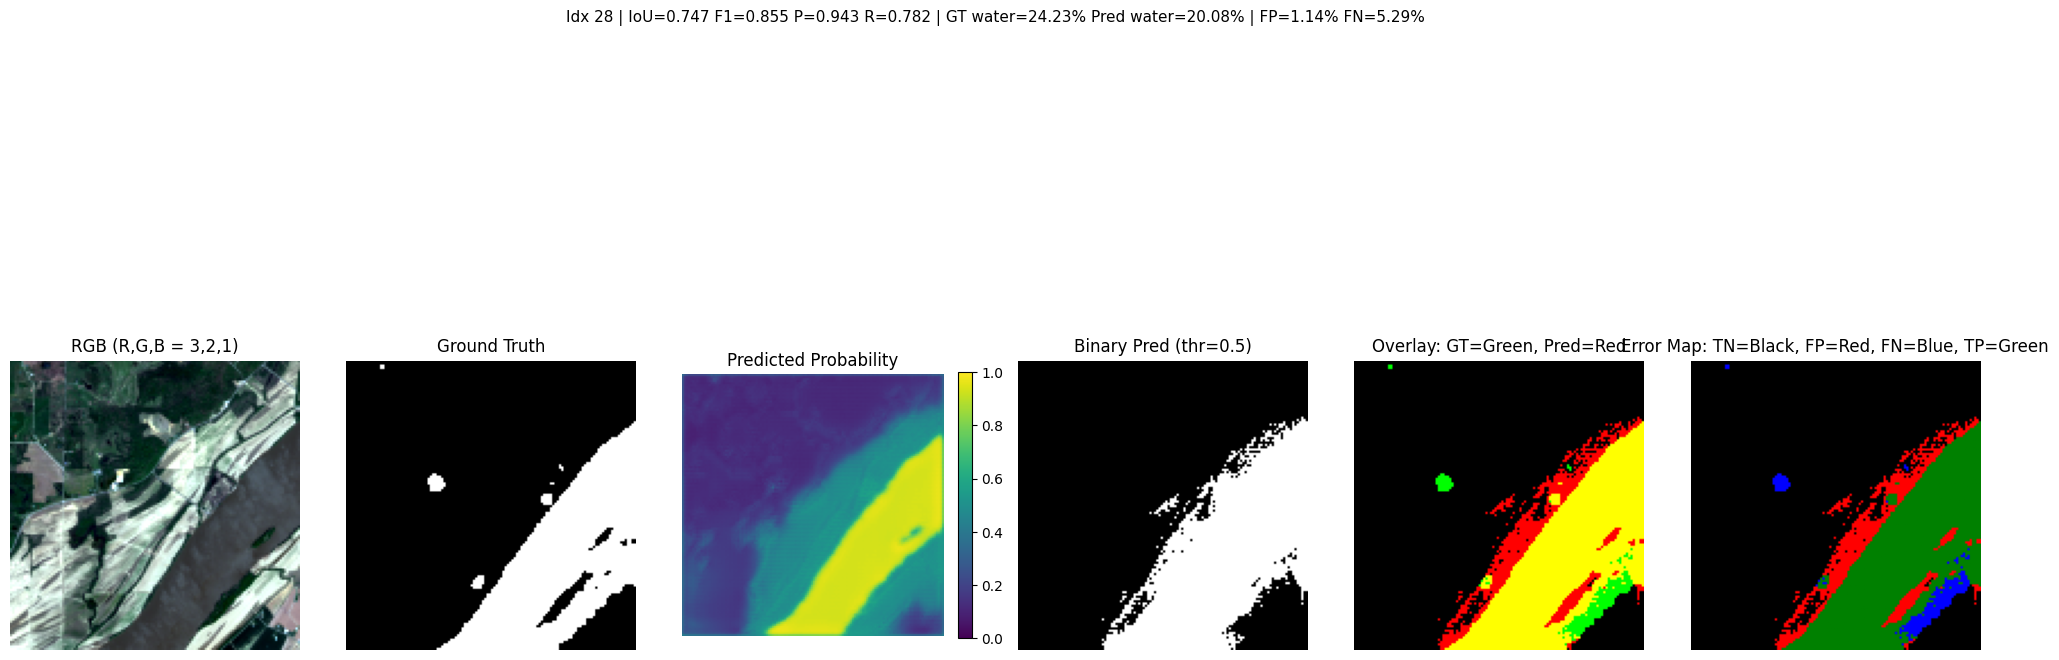

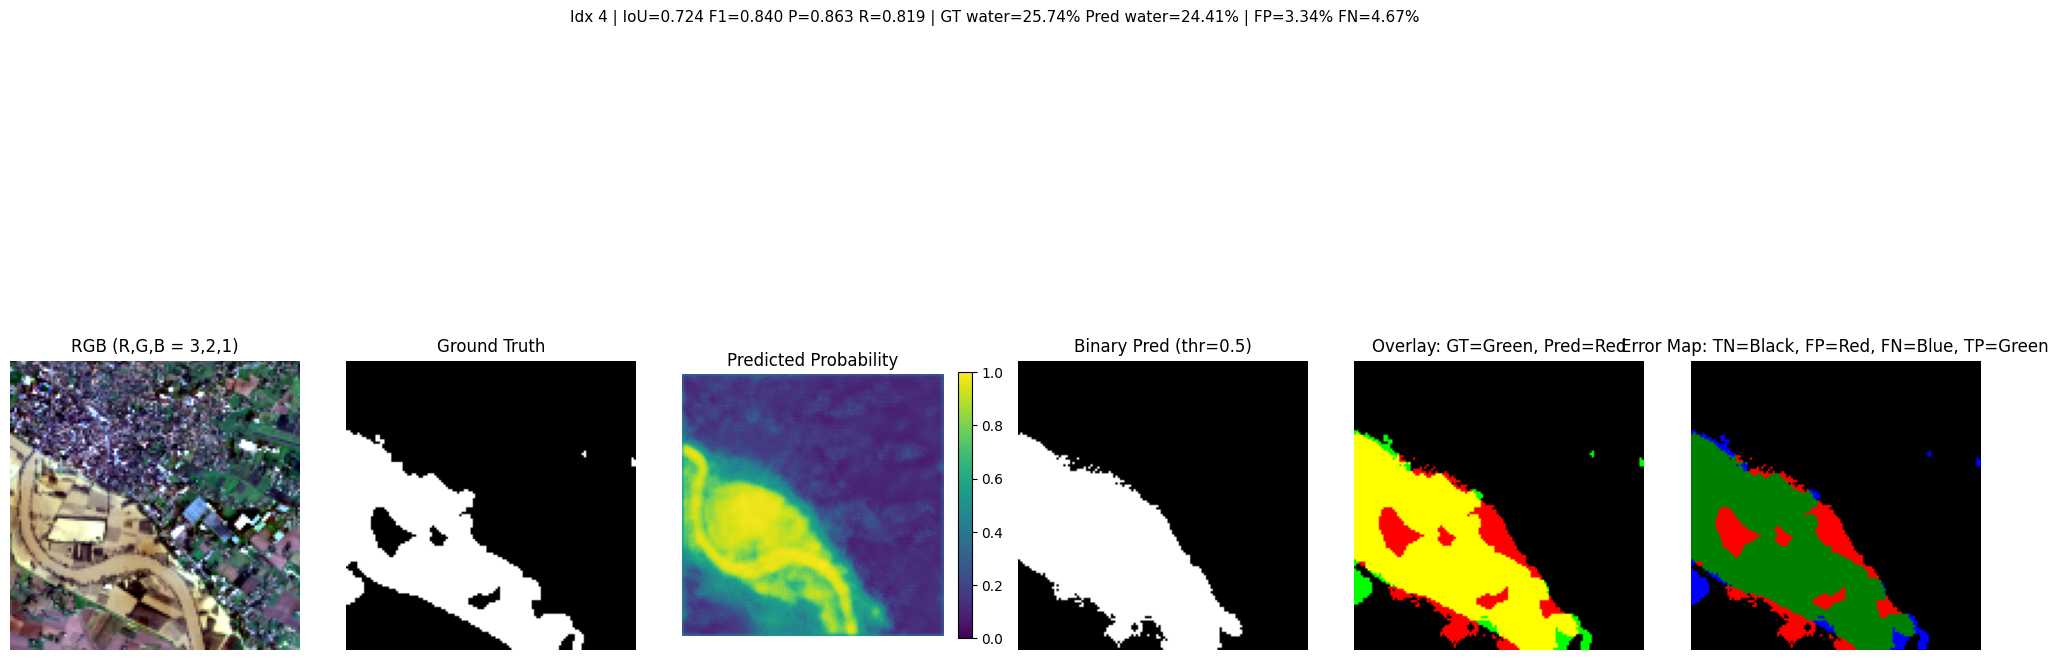

In [188]:
top5 = df_metrics.sort_values("iou", ascending=False).head(5)["index"].tolist()
show_group(top5, "GROUP 1 — Best Predictions (highest IoU)")


GROUP 2 — Worst Predictions (lowest IoU)


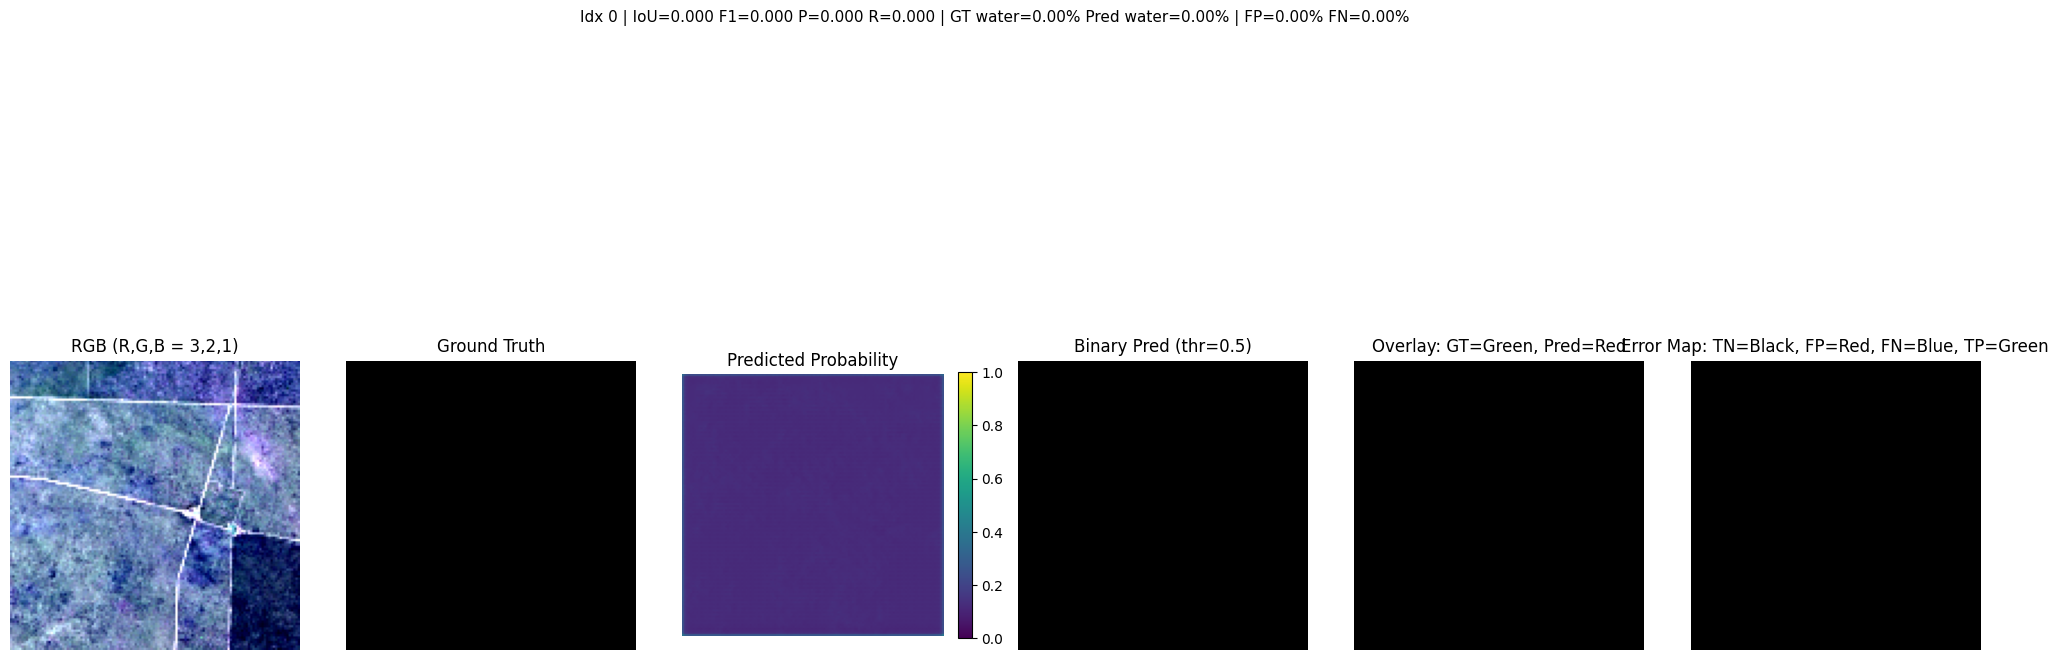

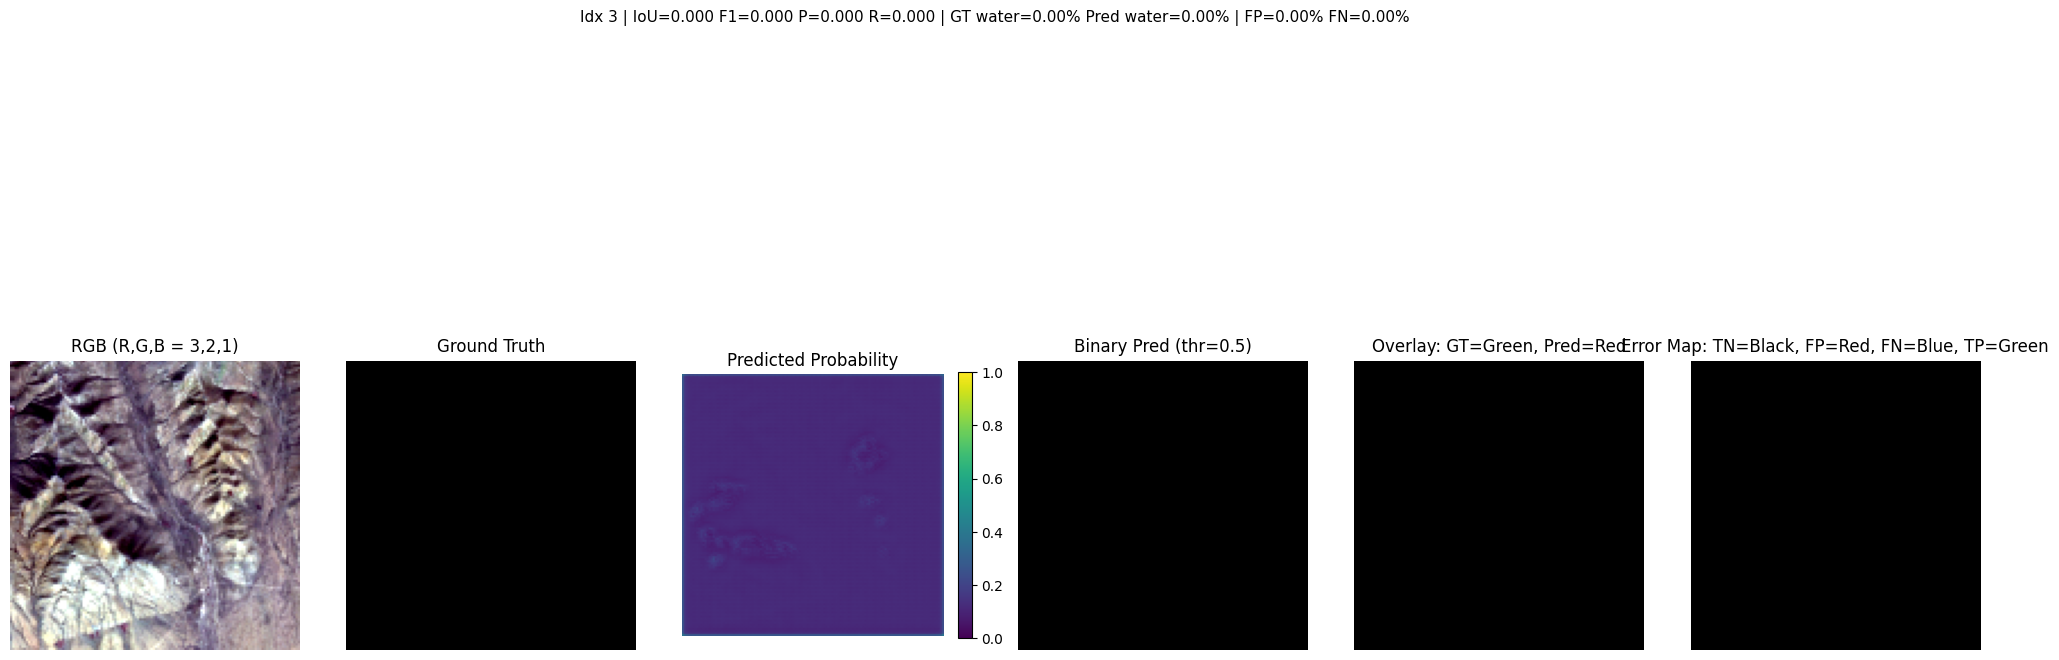

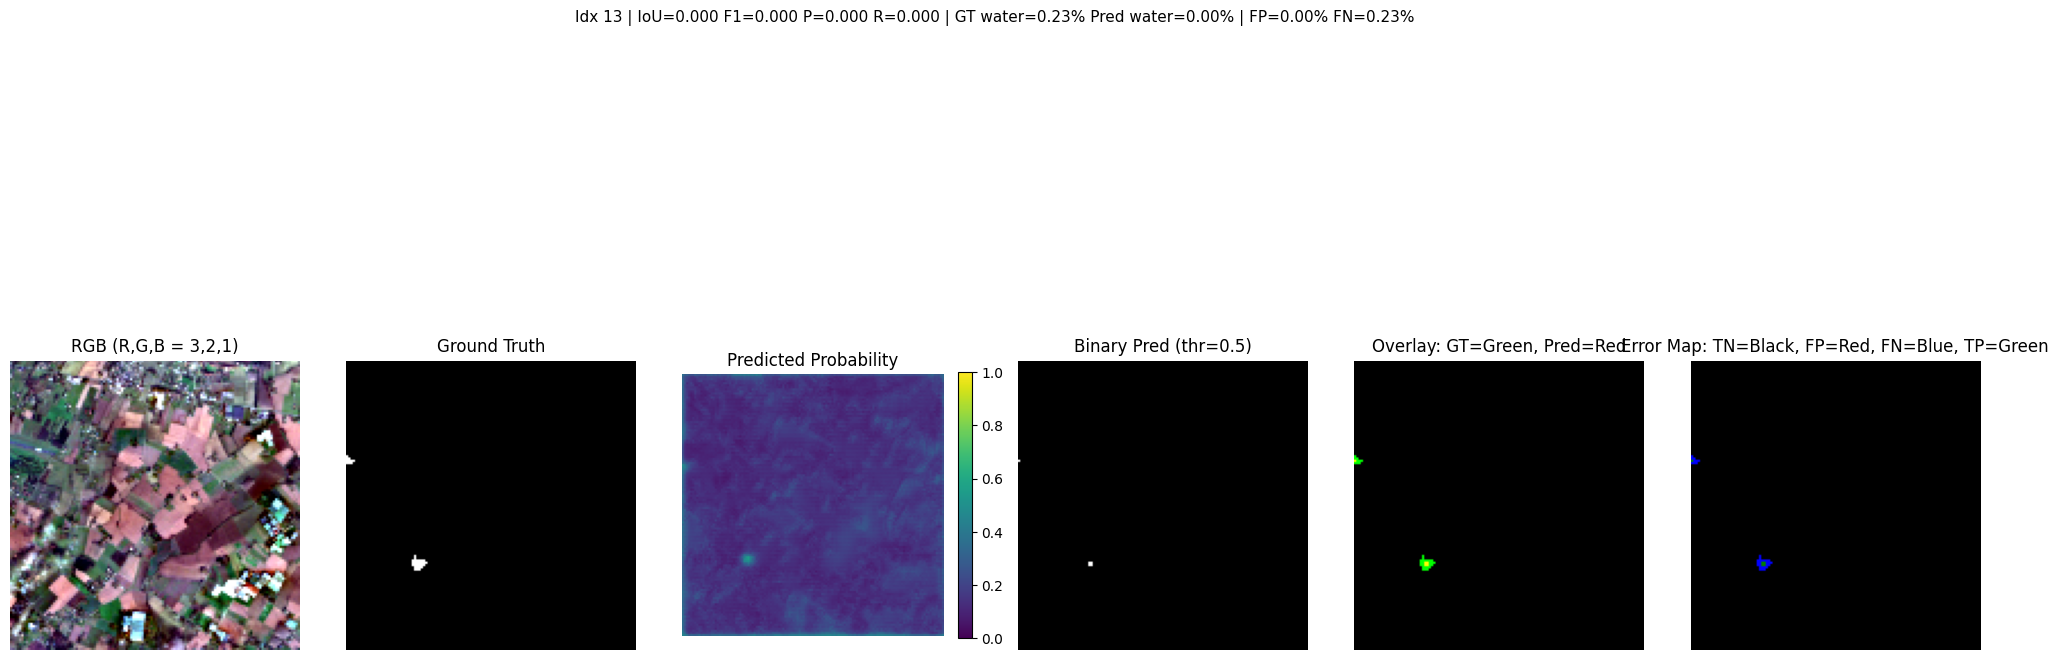

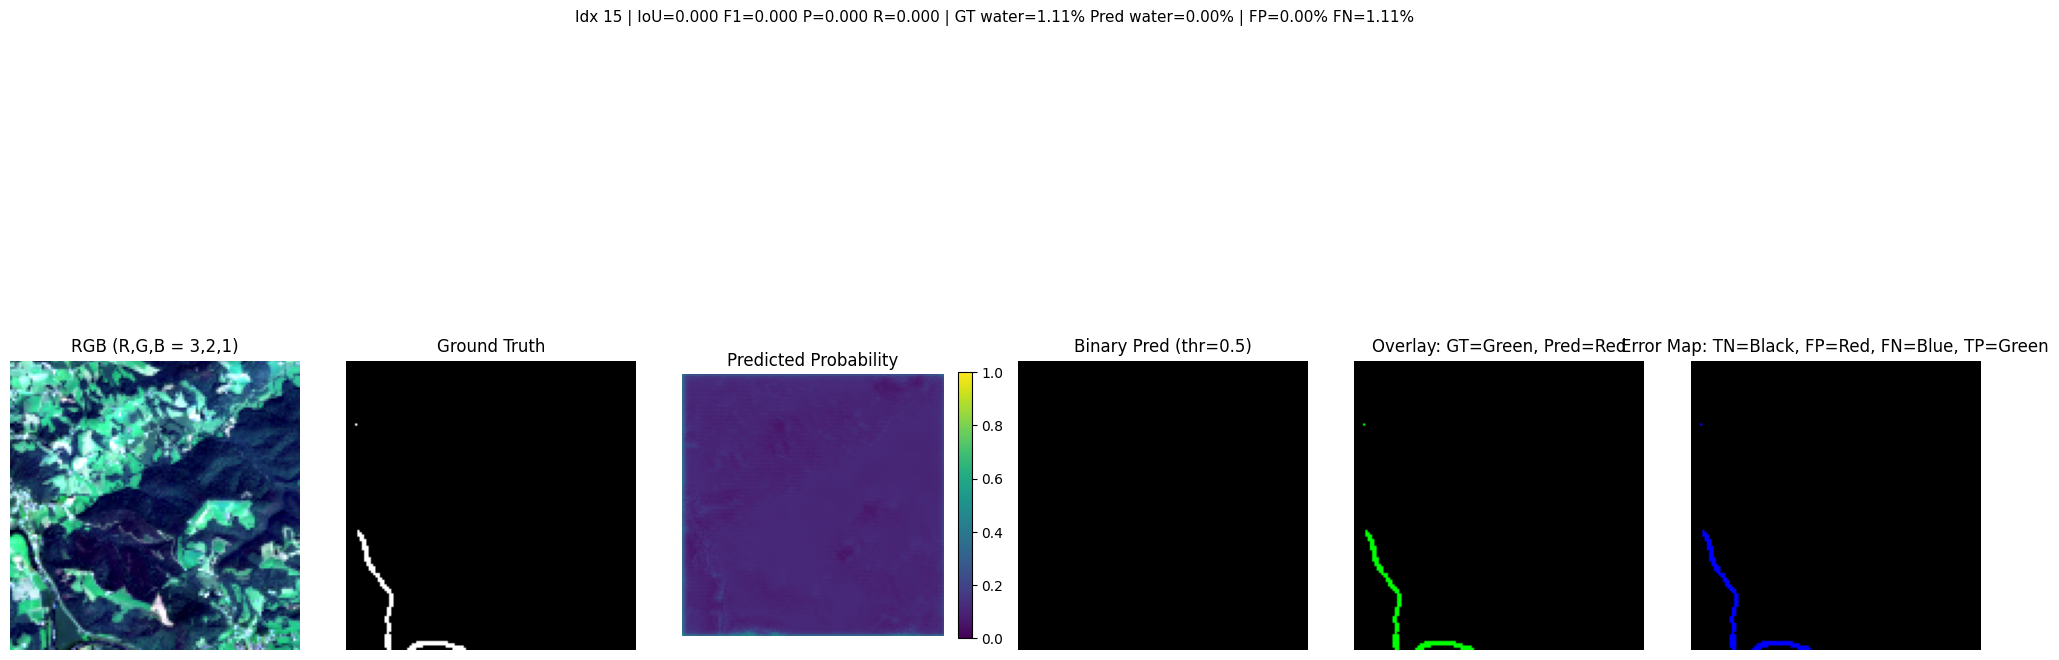

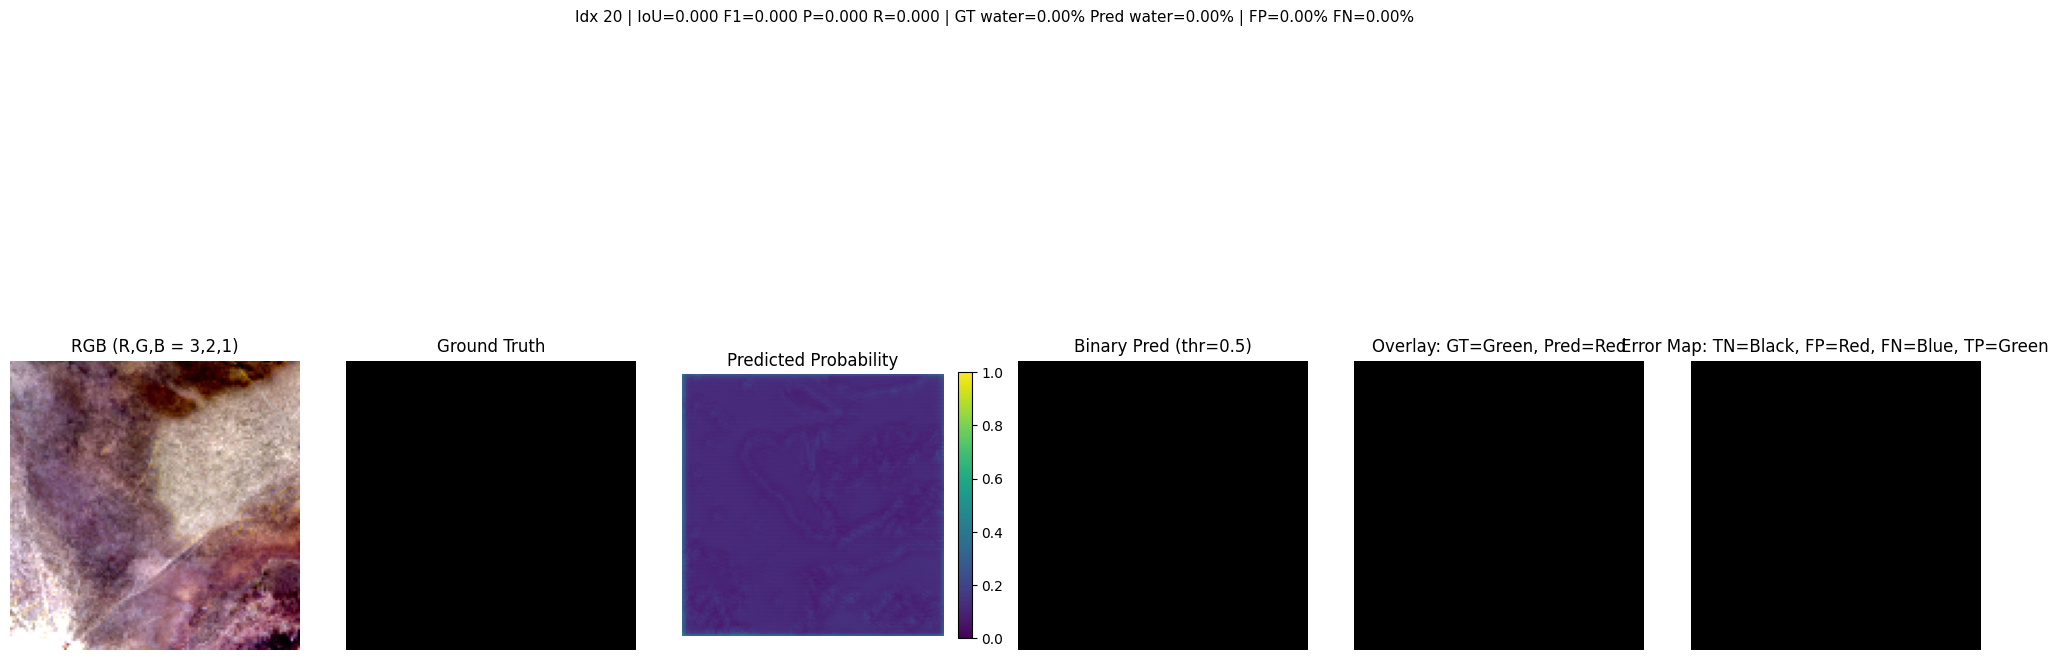

In [189]:
bottom5 = df_metrics.sort_values("iou", ascending=True).head(5)["index"].tolist()
show_group(bottom5, "GROUP 2 — Worst Predictions (lowest IoU)")


GROUP 3 — High False-Positive Cases


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


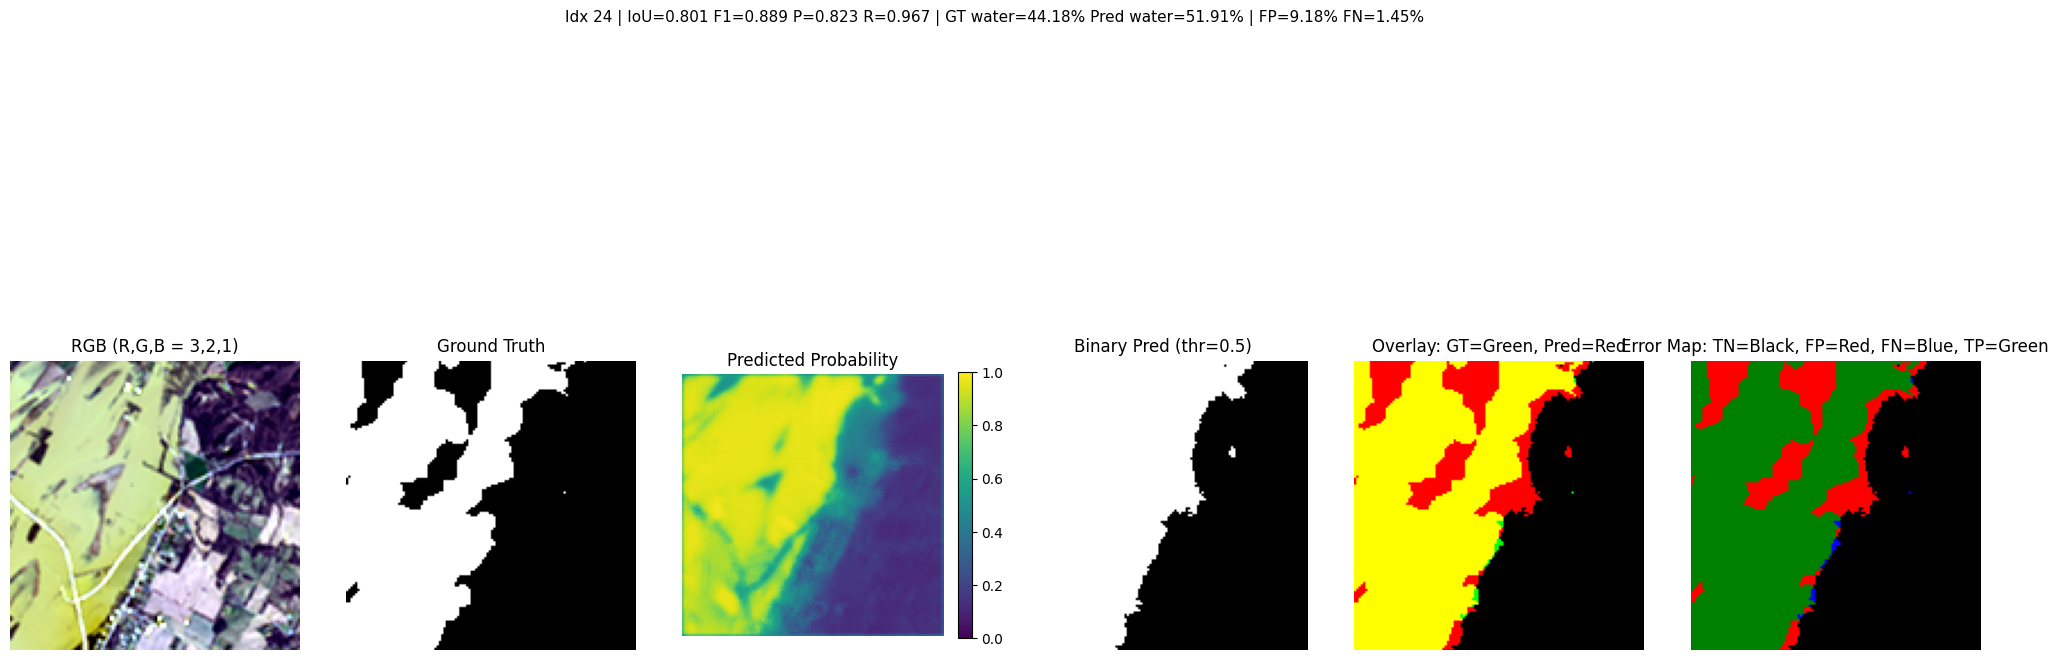

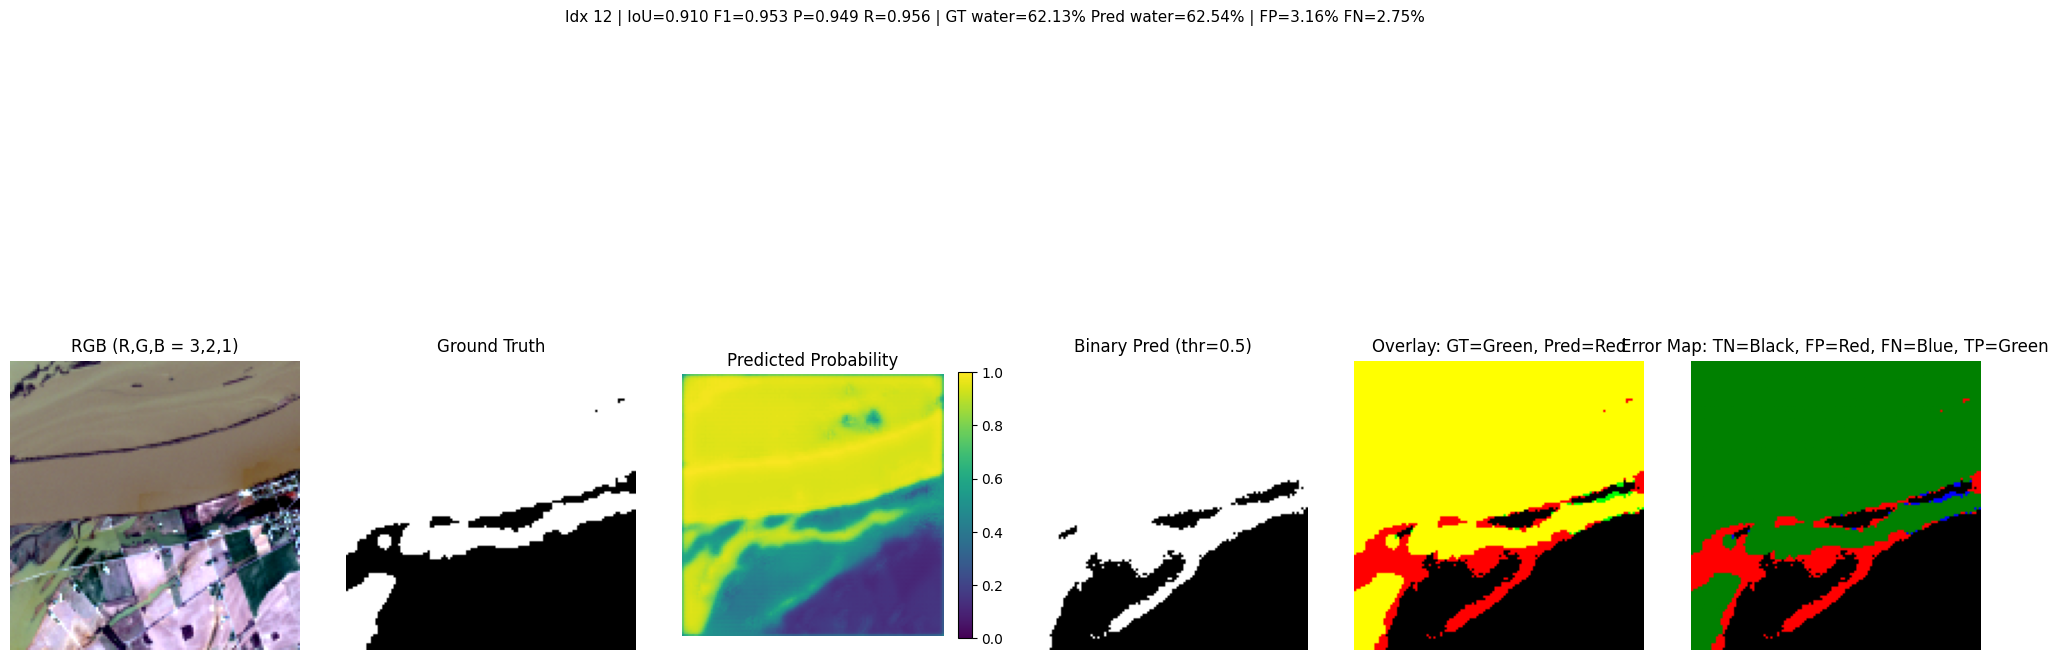

In [190]:
df_fp = df_metrics[df_metrics["pred_water_pct"] > df_metrics["gt_water_pct"]].copy()
df_fp["fp_excess"] = df_fp["pred_water_pct"] - df_fp["gt_water_pct"]
top_fp = df_fp.sort_values("fp_excess", ascending=False).head(5)["index"].tolist()
if len(top_fp) == 0:
    print("No high-FP cases found.")
else:
    show_group(top_fp, "GROUP 3 — High False-Positive Cases")


GROUP 4 — High False-Negative Cases


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


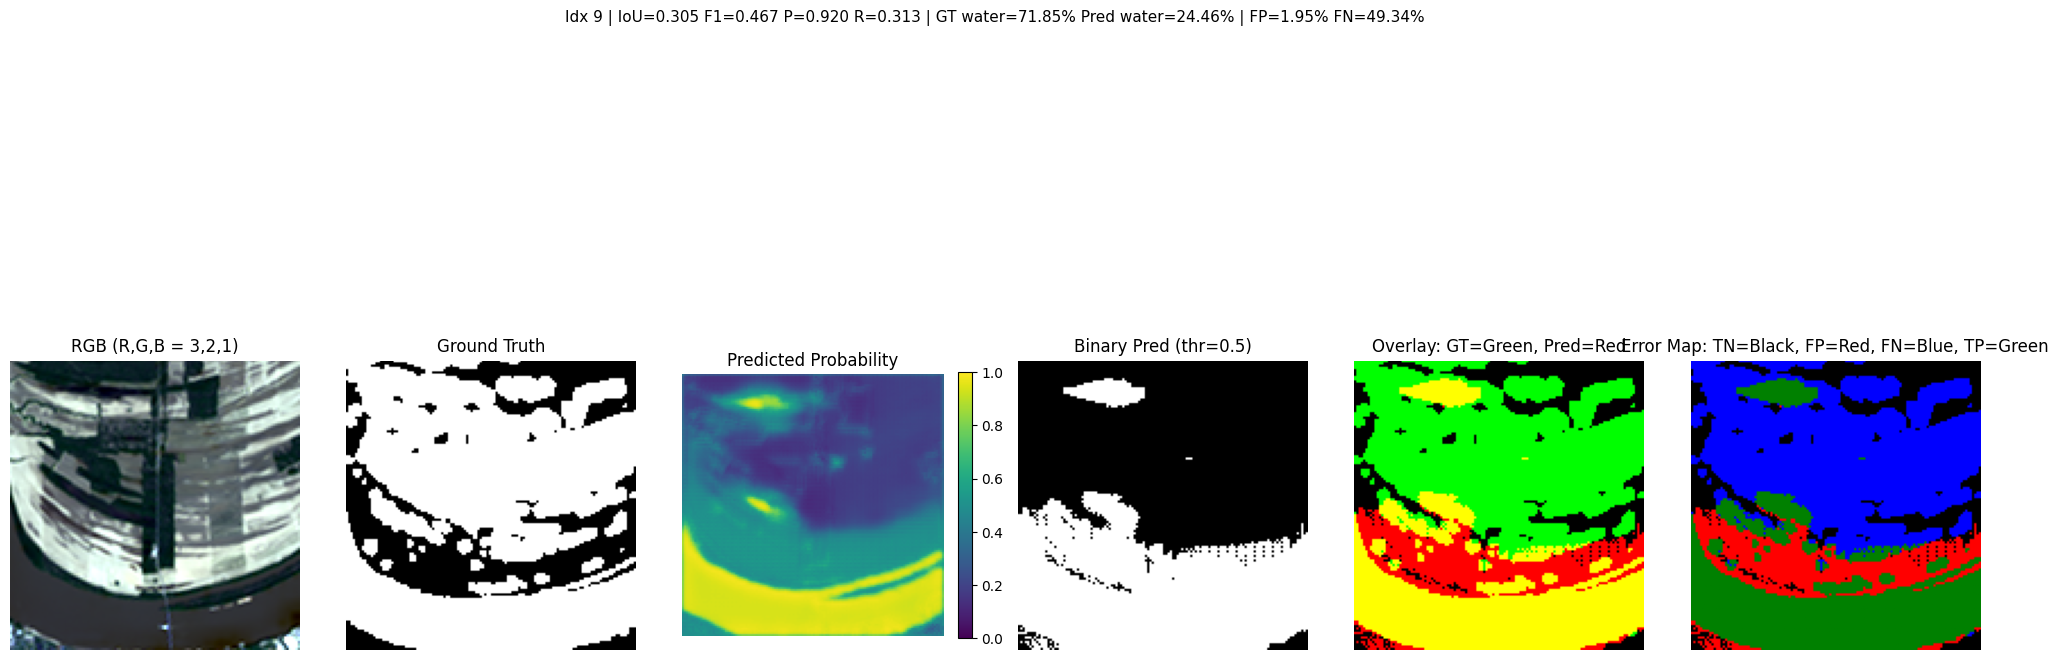

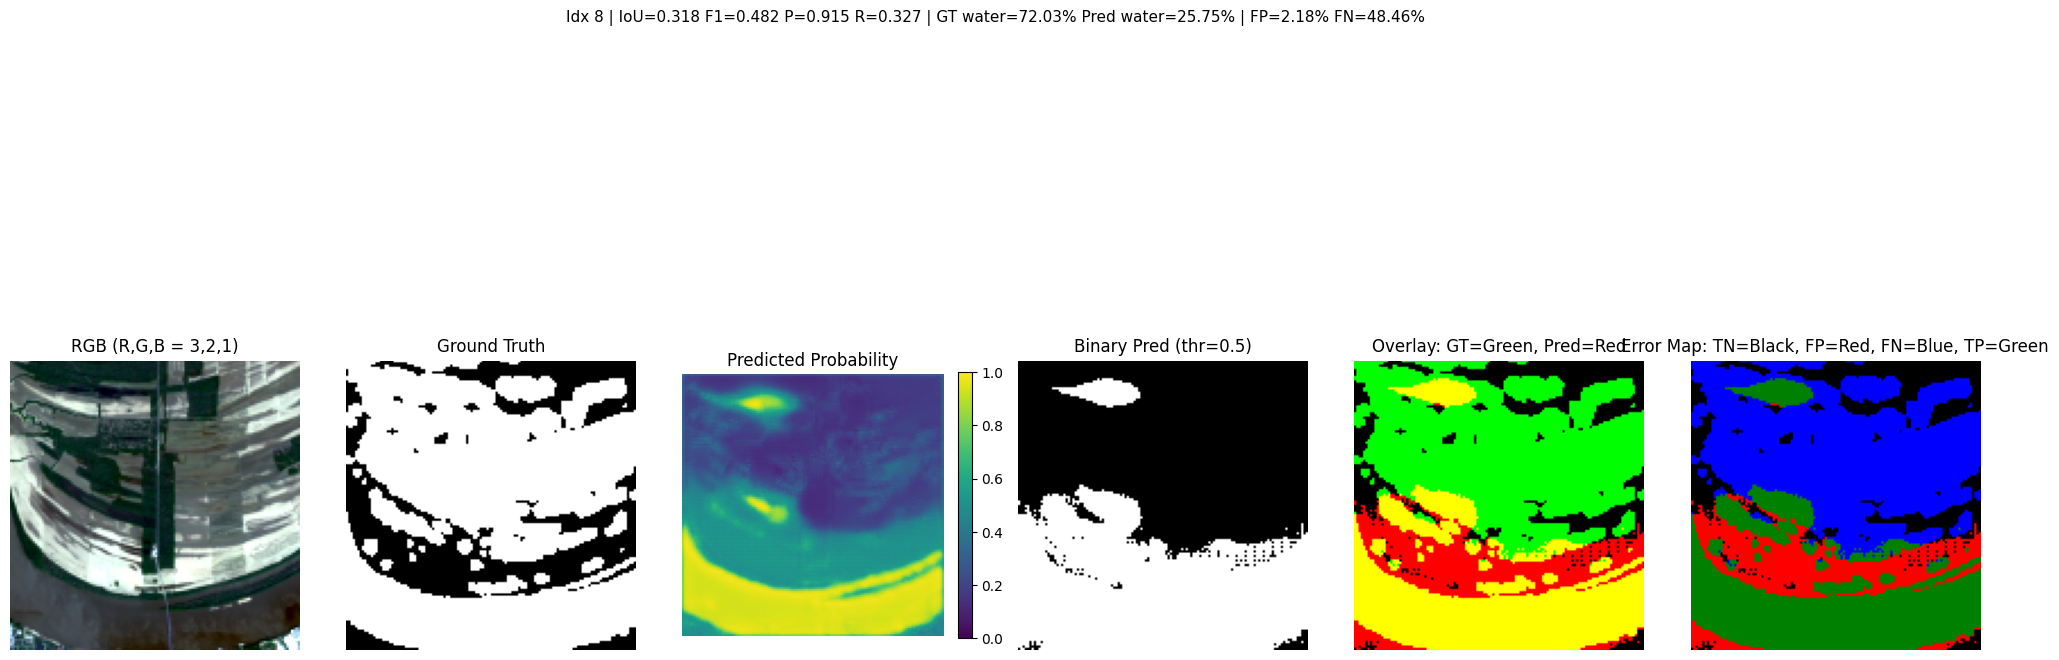

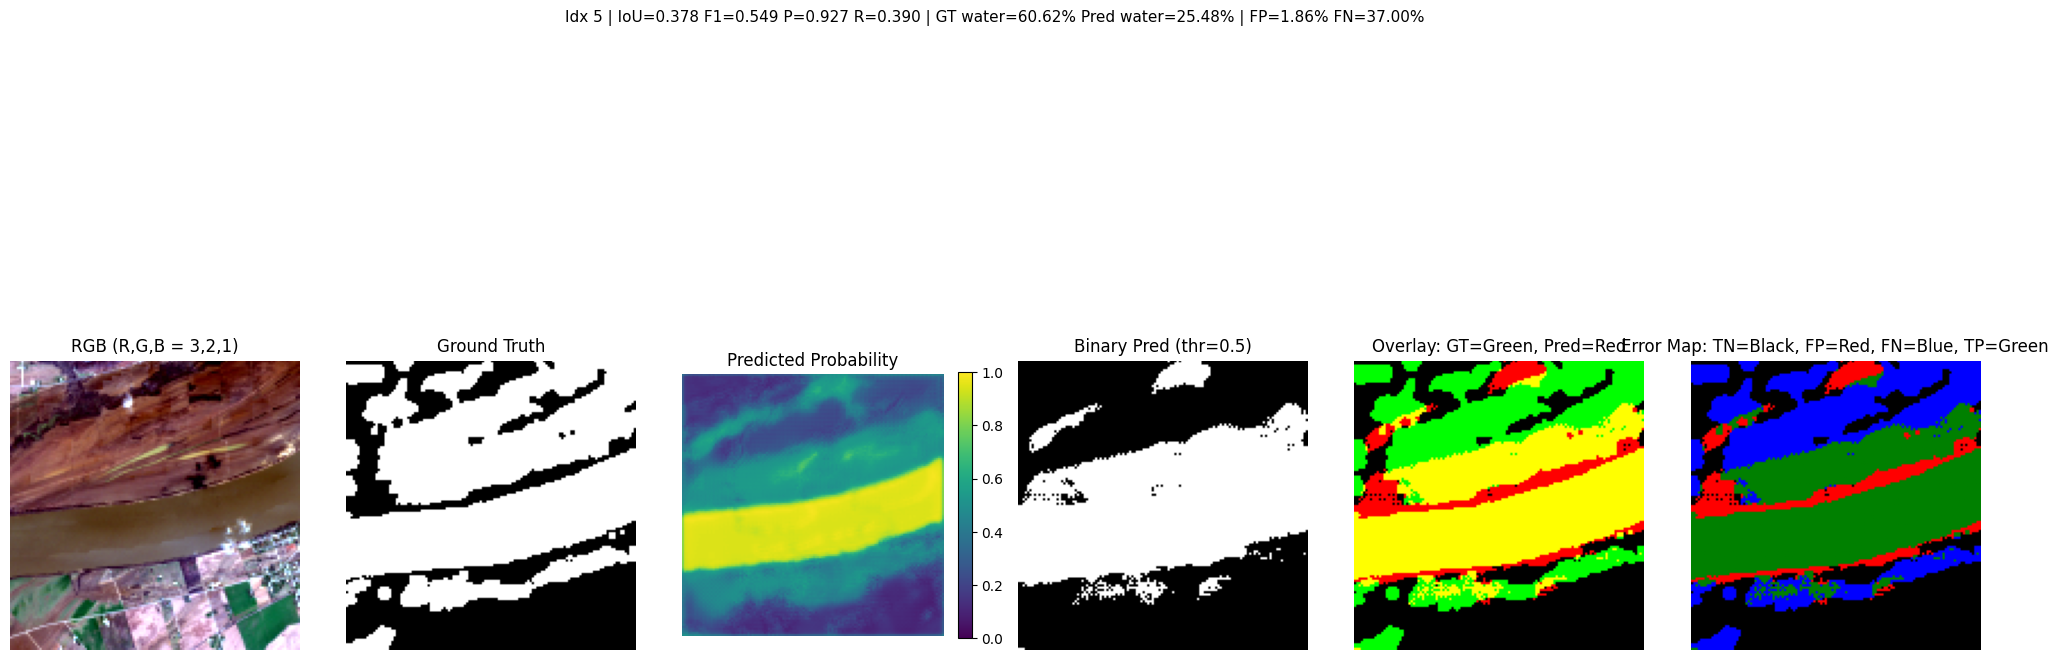

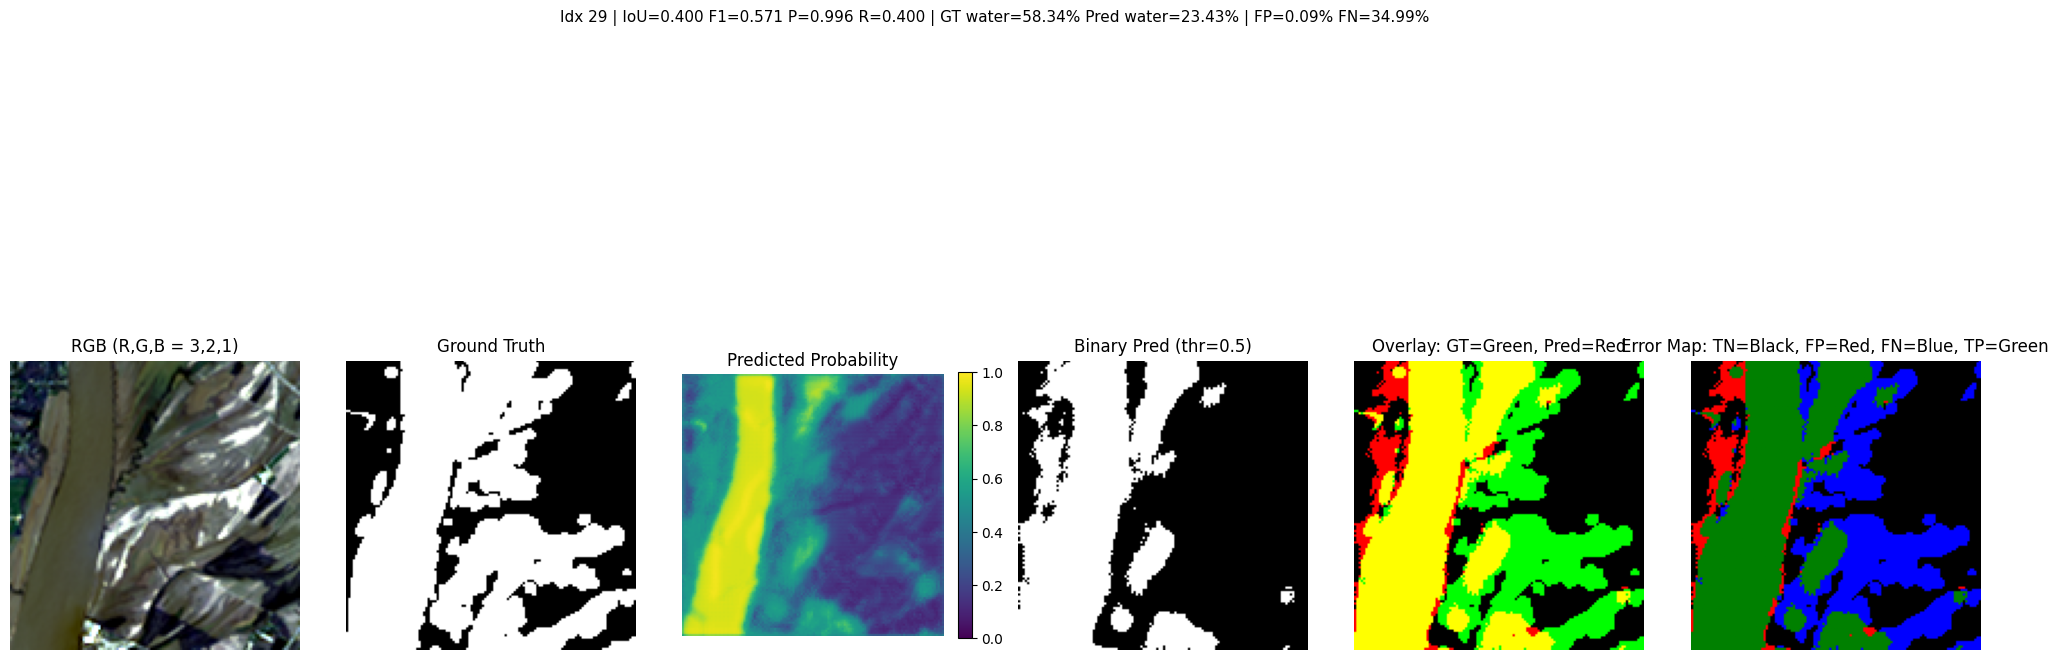

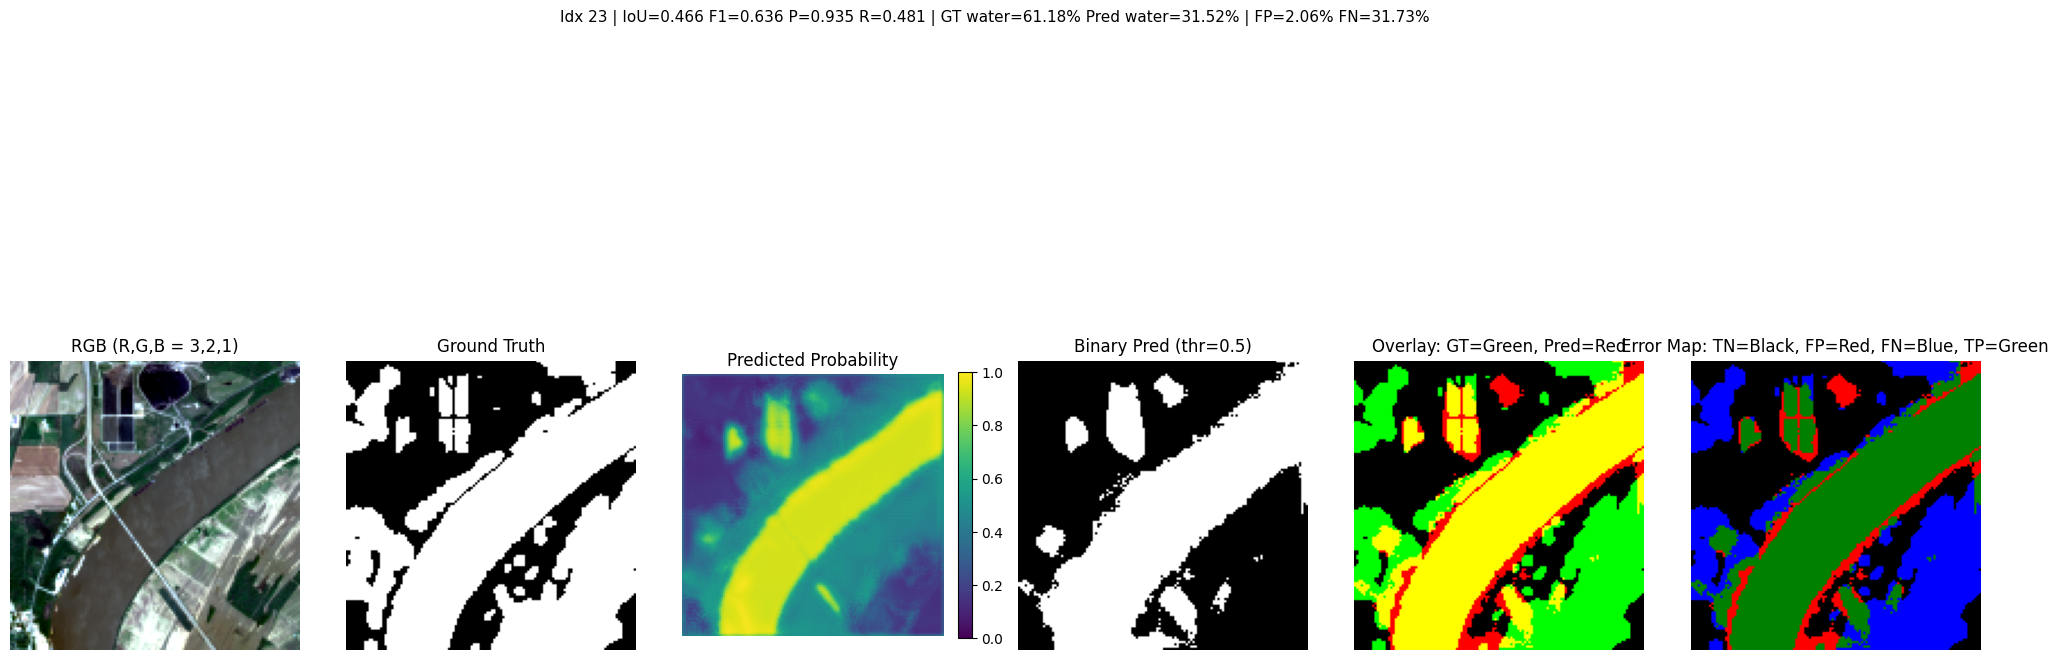

In [191]:
df_fn = df_metrics[df_metrics["gt_water_pct"] > df_metrics["pred_water_pct"]].copy()
df_fn["fn_excess"] = df_fn["gt_water_pct"] - df_fn["pred_water_pct"]
top_fn = df_fn.sort_values("fn_excess", ascending=False).head(5)["index"].tolist()
if len(top_fn) == 0:
    print("No high-FN cases found.")
else:
    show_group(top_fn, "GROUP 4 — High False-Negative Cases")